In [ ]:
"""
Part 1 — ทำความสะอาดข้อมูล (Data Cleaning)
ชุดข้อมูล: UCI Default of Credit Card Clients (ไต้หวัน, เม.ย.–ก.ย. 2005, 30,000 ราย)

สิ่งที่สคริปต์นี้ทำ
    1. โหลดข้อมูลและตรวจโครงสร้าง (จำนวนแถว/คอลัมน์, ชนิดข้อมูล)
    2. หาค่าที่หายไป ทั้งแบบ "ชัดเจน" (NaN/ช่องว่าง) และแบบ "แฝง" (รหัสที่แปลว่าไม่ทราบ)
    3. หารหัสซ้ำ — ID ซ้ำ, แถวซ้ำทั้งแถว, และแถวที่ข้อมูลเหมือนกันแต่ ID ต่างกัน
    4. หารหัสที่เอกสารไม่ได้อธิบายไว้ (EDUCATION 0, MARRIAGE 0, PAY_x = -2/0)
    5. ตรวจค่าตัวเลขที่ดูแปลก (BILL_AMT ติดลบ, ช่วงอายุ, วงเงิน)
    6. จัดการแต่ละปัญหาตามที่ตัดสินใจไว้ (ตัดแถวที่การศึกษา/สถานภาพเป็น "ไม่ทราบ")
    7. สรุปเป็นตารางว่าแต่ละปัญหามีกี่แถว จัดการอย่างไร แล้วบันทึกไฟล์

วิธีรัน (Google Colab)
    1. อัปโหลด UCI_Credit_Card.csv ไว้ที่ไหนก็ได้ใน Google Drive
    2. วางโค้ดนี้ใน cell แล้วรัน — Colab จะขออนุญาตเชื่อม Drive ครั้งแรก
"""

import os                                                   # จัดการ path / เดิน folder
import re                                                   # ตัด " (1)" ท้ายชื่อ file

import pandas as pd                                         # จัดการตารางข้อมูล

# ---------- ตั้งค่า (แก้ตรงนี้) ----------
DATA_FILE = "UCI_Credit_Card.csv"                           # ชื่อ file ข้อมูล
DATA_FOLDER = None                                          # ชื่อ folder ที่เก็บ file (None = หาทั้ง Drive)

# ---------- เชื่อม Google Drive ----------
try:
    from google.colab import drive                          # module ของ Colab
    drive.mount("/content/drive", force_remount=False)      # เชื่อม Drive เข้ากับ /content/drive
    SEARCH_ROOTS = ["/content/drive/MyDrive",               # จุดเริ่มค้นหา = Drive ของฉัน
                    "/content/drive/Shareddrives",          # + Shared drive (ถ้ามี)
                    "/content"]                             # + file ที่อัปโหลดเข้า Colab ตรง ๆ
except ImportError:                                         # ไม่ได้รันบน Colab (เช่นรันในเครื่อง)
    SEARCH_ROOTS = [os.getcwd()]                            # ค้นหาจาก folder ที่รันแทน


def normalize(name):                                        # ทำชื่อ file ให้เทียบกันง่าย
    stem, ext = os.path.splitext(name.lower())              # ตัวเล็กทั้งหมด + แยกนามสกุล
    stem = re.sub(r"\s*\(\d+\)$", "", stem)                # ตัด " (1)" ที่ Drive เติมให้ตอนอัปซ้ำ
    return stem.replace(" ", "_") + ext                     # ช่องว่าง = ขีดล่าง


def find_file(file_name, roots, folder=None):               # function หา file ตามชื่อ
    target = normalize(file_name)                           # ชื่อที่ต้องการ (ทำให้เทียบง่าย)
    csv_seen = []                                           # เก็บ csv ที่เจอไว้ช่วยบอกถ้าหาไม่เจอ
    for root in roots:                                      # ไล่ทุกจุดเริ่มค้นหา
        if not os.path.isdir(root):                         # จุดไหนไม่มีอยู่จริงก็ข้าม
            continue
        for dirpath, dirnames, filenames in os.walk(root):  # เดินลงทุก folder ย่อย
            dirnames[:] = [d for d in dirnames              # ข้าม folder ซ่อน + drive (กันวนซ้ำจาก /content)
                           if not d.startswith(".") and d not in ("drive", "sample_data")]
            if folder and os.path.basename(dirpath) != folder:  # ถ้าระบุ folder แต่ไม่ใช่ folder นี้
                continue                                    # ข้ามไป
            for f in filenames:                             # ไล่ทุก file ใน folder
                if normalize(f) == target:                  # ถ้าชื่อตรง
                    return os.path.join(dirpath, f)         # คืน path ทันที
                if f.lower().endswith(".csv"):              # จด csv อื่นไว้
                    csv_seen.append(os.path.join(dirpath, f))
    hint = "\n  ".join(csv_seen[:20]) or "(ไม่เจอ csv เลย)"  # csv ที่เจอ (สูงสุด 20 file)
    raise FileNotFoundError(                                # หยุดพร้อมบอกว่าเจออะไรบ้าง
        f"หา file ไม่เจอ: {file_name} (folder={folder}) ใน {roots}\n"
        f"csv ที่เจอใน Drive:\n  {hint}\n"
        f"→ แก้ DATA_FILE ให้ตรงกับชื่อจริง หรือตั้ง DATA_FOLDER = None")


INPUT_PATH = find_file(DATA_FILE, SEARCH_ROOTS, DATA_FOLDER)  # path file ข้อมูล
DATA_DIR = os.path.dirname(INPUT_PATH)                      # folder ที่ file อยู่
OUTPUT_PATH = os.path.join(DATA_DIR, "UCI_Credit_Card_clean.csv")  # file ผลลัพธ์ไว้ folder เดียวกัน

print("Folder    :", DATA_DIR)                              # แสดงที่อยู่จริงของ folder
print("Input     :", INPUT_PATH)                            # แสดงที่อยู่จริงของ file ข้อมูล
print("Output    :", OUTPUT_PATH)                           # แสดงที่ที่จะบันทึก file สะอาด

# รหัสที่ "เอกสารต้นฉบับ" (UCI data dictionary) อธิบายไว้ — ใช้เทียบหารหัสแปลกปลอม
DOCUMENTED_CODES = {
    "SEX": {1, 2},                        # 1=ชาย, 2=หญิง
    # 1=บัณฑิตวิทยาลัย, 2=มหาวิทยาลัย, 3=ม.ปลาย, 4=อื่น ๆ, 5=ไม่ทราบ, 6=ไม่ทราบ
    "EDUCATION": {1, 2, 3, 4, 5, 6},
    "MARRIAGE": {1, 2, 3},                # 1=สมรส, 2=โสด, 3=อื่น ๆ
    # PAY_x: -1 = จ่ายตรงเวลา, 1..9 = ค้างชำระ 1..9 เดือน (เอกสารไม่พูดถึง -2 และ 0)
    "PAY": {-1, 1, 2, 3, 4, 5, 6, 7, 8, 9},
}

PAY_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAY_AMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
TARGET = "default.payment.next.month"


def section(title: str) -> None:
    """พิมพ์หัวข้อให้อ่านผลลัพธ์ใน terminal ได้ง่าย"""
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


# ----------------------------------------------------------------------
# 1) โหลดข้อมูล
# ----------------------------------------------------------------------
def load_data(path: str) -> pd.DataFrame:
    # na_values: นับสตริงที่มักใช้แทน "ไม่มีข้อมูล" ให้เป็น NaN ด้วย
    df = pd.read_csv(path, na_values=["", " ", "NA", "N/A", "null", "?"])
    section("1) โครงสร้างข้อมูล")
    print(f"ไฟล์: {path}")
    print(f"จำนวนแถว x คอลัมน์: {df.shape}")
    print(df.dtypes.value_counts().to_string())
    return df


# ----------------------------------------------------------------------
# 2) ค่าที่หายไป
# ----------------------------------------------------------------------
def check_missing(df: pd.DataFrame) -> None:
    section("2) ค่าที่หายไป (Missing values)")
    na = df.isna().sum()
    print(f"NaN ทั้งหมด: {int(na.sum())}")
    if na.sum():
        print(na[na > 0].to_string())

    # ค่าหายไปแบบแฝง: รหัสที่ไม่ได้บอกว่าเป็นอะไร ก็คือ "ไม่ทราบ" นั่นเอง
    hidden = {
        "EDUCATION = 0/5/6 (ไม่ทราบ/ไม่มีในเอกสาร)": int(df["EDUCATION"].isin([0, 5, 6]).sum()),
        "MARRIAGE = 0 (ไม่ทราบ)": int((df["MARRIAGE"] == 0).sum()),
    }
    print("\nค่าที่หายไปแบบแฝง (ซ่อนอยู่ในรูปของรหัส):")
    for k, v in hidden.items():
        print(f"  {k:<40} {v:>6} แถว ({v / len(df):.2%})")


# ----------------------------------------------------------------------
# 3) รหัสซ้ำ / แถวซ้ำ
# ----------------------------------------------------------------------
def check_duplicates(df: pd.DataFrame) -> pd.Series:
    section("3) ข้อมูลซ้ำ (Duplicates)")
    print(f"ID ซ้ำ                         : {df['ID'].duplicated().sum()}")
    print(f"แถวซ้ำทั้งแถว (รวม ID)          : {df.duplicated().sum()}")

    features = [c for c in df.columns if c not in ("ID", TARGET)]
    dup_mask = df.duplicated(subset=features, keep=False)
    groups = df[dup_mask].groupby(features)[TARGET]
    n_conflict = int((groups.nunique() > 1).sum())
    all_zero = (df.loc[dup_mask, BILL_COLS + PAY_AMT_COLS] == 0).all(axis=1).mean()

    print(f"แถวที่ feature เหมือนกันแต่ ID ต่าง: {int(dup_mask.sum())} แถว ใน {groups.ngroups} กลุ่ม")
    print(f"  - กลุ่มที่ผลลัพธ์ (default) ต่างกัน : {n_conflict} กลุ่ม")
    print(f"  - แถวที่ยอดบิล/ยอดจ่ายเป็น 0 ทั้งหมด: {all_zero:.0%}")
    return dup_mask


# ----------------------------------------------------------------------
# 4) รหัสที่เอกสารไม่ได้อธิบาย
# ----------------------------------------------------------------------
def check_undocumented_codes(df: pd.DataFrame) -> None:
    section("4) รหัสที่เอกสารไม่ได้อธิบายไว้")
    for col in ["SEX", "EDUCATION", "MARRIAGE"]:
        counts = df[col].value_counts().sort_index()
        bad = counts[~counts.index.isin(DOCUMENTED_CODES[col])]
        print(f"{col:<10} ทั้งหมด: {counts.to_dict()}")
        print(f"{'':<10} ไม่มีในเอกสาร: {bad.to_dict() if len(bad) else '-'}")

    print("\nPAY_x — จำนวนแถวที่มีรหัส -2 และ 0 (ไม่มีในเอกสาร):")
    for col in PAY_COLS:
        print(f"  {col}: -2 = {(df[col] == -2).sum():>5}, 0 = {(df[col] == 0).sum():>5}")


# ----------------------------------------------------------------------
# 5) ค่าตัวเลขที่ดูแปลก
# ----------------------------------------------------------------------
def check_numeric_ranges(df: pd.DataFrame) -> None:
    section("5) ตรวจช่วงค่าตัวเลข")
    print(df[["LIMIT_BAL", "AGE"] + BILL_COLS + PAY_AMT_COLS].describe().T[["min", "max"]].to_string())
    neg = (df[BILL_COLS] < 0).any(axis=1).sum()
    print(f"\nแถวที่มี BILL_AMT ติดลบอย่างน้อย 1 เดือน: {neg}")
    print(f"PAY_AMT ติดลบ: {(df[PAY_AMT_COLS] < 0).any(axis=1).sum()}  |  "
          f"LIMIT_BAL <= 0: {(df['LIMIT_BAL'] <= 0).sum()}  |  "
          f"AGE นอกช่วง 18-100: {(~df['AGE'].between(18, 100)).sum()}")


# ----------------------------------------------------------------------
# 6) จัดการข้อมูลตามที่ตัดสินใจ
# ----------------------------------------------------------------------
def clean(df: pd.DataFrame, dup_mask: pd.Series) -> pd.DataFrame:
    section("6) จัดการข้อมูล")
    df = df.copy()

    # 6.1 เปลี่ยนชื่อ target (มีจุด ใช้ยากใน pandas) -> DEFAULT
    #     สถานะชำระคงชื่อเดิมตามต้นฉบับ: PAY_0 (ก.ย.), PAY_2 (ส.ค.) ... PAY_6 (เม.ย.)
    df = df.rename(columns={TARGET: "DEFAULT"})
    pay_cols = PAY_COLS

    # 6.2 ธงแถวที่ feature ซ้ำกัน -> ไม่ลบ แต่ทำธงไว้ให้ตรวจสอบภายหลัง
    #     (ต้องทำก่อนตัดแถวในข้อ 6.3 เพราะ dup_mask คำนวณจากข้อมูลเต็ม 30,000 แถว)
    df["DUP_PROFILE"] = dup_mask.astype(int)

    # 6.3 ตัดแถวที่การศึกษา/สถานภาพสมรสเป็น "ไม่ทราบ" หรือไม่มีในเอกสาร
    #     EDUCATION 5, 6 = ไม่ทราบ (ตามเอกสาร), EDUCATION 0 และ MARRIAGE 0 = ไม่มีในเอกสาร
    #     เหตุผล: ตีความไม่ได้ + เป็นหมวดหมู่ เติมค่าแทนอย่างสมเหตุสมผลไม่ได้
    #            + มีแค่ ~1.3% ของข้อมูล ตัดแล้วอัตรา default แทบไม่เปลี่ยน
    unknown = df["EDUCATION"].isin([0, 5, 6]) | (df["MARRIAGE"] == 0)   # แถวที่ไม่รู้ค่า
    rate_before = df["DEFAULT"].mean()                                   # อัตรา default ก่อนตัด
    rate_dropped = df.loc[unknown, "DEFAULT"].mean()                     # อัตรา default ของกลุ่มที่ตัด
    df = df[~unknown].reset_index(drop=True)                             # เก็บเฉพาะแถวที่รู้ค่า
    print(f"ตัดแถวที่ไม่ทราบการศึกษา/สถานภาพ: {int(unknown.sum())} แถว "
          f"({unknown.mean():.1%}) เหลือ {len(df)} แถว")
    print(f"  อัตรา default: ก่อนตัด {rate_before:.1%} -> หลังตัด {df['DEFAULT'].mean():.1%} "
          f"(กลุ่มที่ตัด {rate_dropped:.1%})")
    print(f"EDUCATION หลังตัด: {df['EDUCATION'].value_counts().sort_index().to_dict()}")
    print(f"MARRIAGE  หลังตัด: {df['MARRIAGE'].value_counts().sort_index().to_dict()}")

    # 6.4 PAY_x: เก็บรหัสเดิมไว้ (DELAY_1 มาจาก PAY_0, DELAY_2 จาก PAY_2, ... เลขตามเดือนเหมือน BILL_AMT)
    #     เก็บรหัสเดิมไว้ (มีข้อมูลพฤติกรรม) + สร้างคอลัมน์ "จำนวนเดือนที่ค้าง"
    #   -2 = ไม่มีการใช้บัตร, -1 = จ่ายเต็ม, 0 = จ่ายขั้นต่ำ (revolving) -> ทั้งหมดคือ "ไม่ค้าง" = 0
    for i, col in enumerate(pay_cols, start=1):
        df[f"DELAY_{i}"] = df[col].clip(lower=0)
    print("สร้าง DELAY_1..DELAY_6 = จำนวนเดือนที่ค้างชำระ (รหัส -2/-1/0 -> 0)")

    # 6.5 BILL_AMT ติดลบ = ลูกค้าจ่ายเกิน (มียอดเครดิตคงเหลือ) -> เก็บไว้ + ทำธง
    df["HAS_CREDIT_BALANCE"] = (df[BILL_COLS] < 0).any(axis=1).astype(int)

    # 6.6 ชนิดข้อมูล: ยอดเงินเป็นจำนวนเต็มอยู่แล้ว (float เพราะรูปแบบไฟล์) -> int
    money = ["LIMIT_BAL"] + BILL_COLS + PAY_AMT_COLS
    df[money] = df[money].round().astype("int64")

    print(f"\nขนาดข้อมูลหลังทำความสะอาด: {df.shape}")
    return df


# ----------------------------------------------------------------------
# 7) ตารางสรุปจำนวนข้อมูล
# ----------------------------------------------------------------------
def summary_table(raw: pd.DataFrame, clean_df: pd.DataFrame, dup_mask: pd.Series) -> pd.DataFrame:
    section("7) ตารางสรุปจำนวนข้อมูล")
    n = len(raw)                                                         # จำนวนแถวเริ่มต้น
    edu_unknown = raw["EDUCATION"].isin([0, 5, 6])                       # การศึกษาไม่ทราบ
    mar_unknown = raw["MARRIAGE"] == 0                                   # สถานภาพไม่ทราบ
    dropped = edu_unknown | mar_unknown                                  # แถวที่ตัด (นับไม่ซ้ำ)

    rows = [  # (รายการ, จำนวนแถว, วิธีจัดการ)
        ("ข้อมูลเริ่มต้น", n, "-"),
        ("ค่าว่าง (NaN) — แถวที่มีอย่างน้อย 1 ช่อง", int(raw.isna().any(axis=1).sum()), "ไม่มี ไม่ต้องทำ"),
        ("ID ซ้ำ", int(raw["ID"].duplicated().sum()), "ไม่มี ไม่ต้องทำ"),
        ("แถวซ้ำทั้งแถว", int(raw.duplicated().sum()), "ไม่มี ไม่ต้องทำ"),
        ("ข้อมูลเหมือนกันแต่ ID ต่าง", int(dup_mask.sum()), "เก็บไว้ + ธง DUP_PROFILE"),
        ("EDUCATION = 0 (ไม่มีในเอกสาร)", int((raw["EDUCATION"] == 0).sum()), "ตัดออก"),
        ("EDUCATION = 5 (ไม่ทราบ)", int((raw["EDUCATION"] == 5).sum()), "ตัดออก"),
        ("EDUCATION = 6 (ไม่ทราบ)", int((raw["EDUCATION"] == 6).sum()), "ตัดออก"),
        ("MARRIAGE = 0 (ไม่มีในเอกสาร)", int(mar_unknown.sum()), "ตัดออก"),
        ("รวมแถวที่ตัดออก (นับไม่ซ้ำ)", int(dropped.sum()), "ตัดออก"),
        ("BILL_AMT ติดลบ (จ่ายเกิน)", int((raw[BILL_COLS] < 0).any(axis=1).sum()), "เก็บไว้ + ธง HAS_CREDIT_BALANCE"),
        ("ข้อมูลหลังทำความสะอาด", len(clean_df), "-"),
    ]
    table = pd.DataFrame(rows, columns=["รายการ", "จำนวนแถว", "วิธีจัดการ"])
    table["% ของทั้งหมด"] = (table["จำนวนแถว"] / n * 100).round(2)  # สัดส่วนเทียบกับ 30,000 แถว
    table = table[["รายการ", "จำนวนแถว", "% ของทั้งหมด", "วิธีจัดการ"]]
    try:                                                                 # ใน Colab/Jupyter แสดงเป็นตารางสวย ๆ
        from IPython import get_ipython
        from IPython.display import display
        if get_ipython() is None:
            raise ImportError
        display(table.style.hide(axis="index"))
    except ImportError:                                                  # รันนอก notebook -> พิมพ์เป็นข้อความ
        print(table.to_string(index=False))

    print(f"\nคอลัมน์: {raw.shape[1]} -> {clean_df.shape[1]}  |  "
          f"อัตรา default: {raw[TARGET].mean():.1%} -> {clean_df['DEFAULT'].mean():.1%}")
    return table


def main() -> None:
    df = load_data(INPUT_PATH)
    check_missing(df)
    dup_mask = check_duplicates(df)
    check_undocumented_codes(df)
    check_numeric_ranges(df)
    clean_df = clean(df, dup_mask)

    summary_table(df, clean_df, dup_mask)

    clean_df.to_csv(OUTPUT_PATH, index=False)
    print(f"\nบันทึกไฟล์: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()


In [ ]:
"""
Part 1 (ต่อ) — ตารางสรุปข้อมูลหลังทำความสะอาด
รันต่อจาก part1_data_cleaning.py (ใช้ cell ถัดไปใน Colab ได้เลย)

ตารางที่ได้
    1. ภาพรวมข้อมูล        — จำนวนแถว/คอลัมน์, จำนวนและอัตราผิดนัดชำระ
    2. พจนานุกรมตัวแปร      — แต่ละคอลัมน์คืออะไร ชนิดข้อมูล ค่าต่ำสุด/สูงสุด
    3. ตัวแปรหมวดหมู่       — เพศ / การศึกษา / สถานภาพ: จำนวน, %, อัตรา default ของแต่ละกลุ่ม
    4. ตัวแปรตัวเลข          — วงเงิน, อายุ, ยอดบิล, ยอดจ่าย: mean, median, SD, min, max
    5. สถานะการชำระ (PAY)  — แต่ละเดือนมีกี่คนจ่ายตรง / ค้างกี่เดือน
"""

import os                                                   # จัดการ path / เดิน folder

import pandas as pd                                         # จัดการตารางข้อมูล

# ---------- หา file ข้อมูลที่สะอาดแล้ว ----------
CLEAN_FILE = "UCI_Credit_Card_clean.csv"                    # file ที่ part1_data_cleaning.py บันทึกไว้

if "OUTPUT_PATH" in globals() and os.path.isfile(OUTPUT_PATH):  # ถ้ารัน cell ก่อนหน้าแล้ว ใช้ path เดิมเลย
    CLEAN_PATH = OUTPUT_PATH
else:                                                       # ไม่งั้นค้นหา file เอง (เหมือน cell ก่อนหน้า)
    try:
        from google.colab import drive                      # module ของ Colab
        drive.mount("/content/drive", force_remount=False)  # เชื่อม Drive
        roots = ["/content/drive/MyDrive", "/content"]      # จุดเริ่มค้นหา
    except ImportError:                                     # ไม่ได้รันบน Colab
        roots = [os.getcwd()]                               # ค้นหาจาก folder ที่รัน
    CLEAN_PATH = None
    for root in roots:                                      # ไล่ทุกจุดเริ่มค้นหา
        for dirpath, dirnames, filenames in os.walk(root):  # เดินลงทุก folder ย่อย
            dirnames[:] = [d for d in dirnames if not d.startswith(".") and d != "drive"]
            if CLEAN_FILE in filenames:                     # เจอ file
                CLEAN_PATH = os.path.join(dirpath, CLEAN_FILE)
                break
        if CLEAN_PATH:
            break
    assert CLEAN_PATH, f"หา {CLEAN_FILE} ไม่เจอ — รัน part1_data_cleaning.py ก่อน"

df = pd.read_csv(CLEAN_PATH)                                # โหลดข้อมูลที่สะอาดแล้ว
print("ใช้ file:", CLEAN_PATH)

# ---------- ป้ายชื่อของรหัส (ตามเอกสาร) ----------
LABELS = {
    "SEX": {1: "ชาย", 2: "หญิง"},
    "EDUCATION": {1: "บัณฑิตวิทยาลัย", 2: "มหาวิทยาลัย", 3: "มัธยมศึกษาตอนปลาย", 4: "อื่น ๆ"},
    "MARRIAGE": {1: "สมรส", 2: "โสด", 3: "อื่น ๆ"},
}
PAY_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]  # สถานะการชำระ 6 เดือน (ชื่อตามต้นฉบับ)
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]           # ยอดบิล 6 เดือน
PAY_AMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]         # ยอดจ่าย 6 เดือน
MONTHS = ["ก.ย.", "ส.ค.", "ก.ค.", "มิ.ย.", "พ.ค.", "เม.ย."]  # เดือนที่ 1..6 (ปี 2005)


def show(title, table):                                     # แสดงตาราง: Colab = HTML, นอก notebook = ข้อความ
    print("\n" + "=" * 70 + f"\n{title}\n" + "=" * 70)
    try:
        from IPython import get_ipython
        from IPython.display import display
        if get_ipython() is None:
            raise ImportError
        display(table.style.hide(axis="index").format(precision=2, thousands=","))
    except ImportError:
        print(table.round(2).to_string(index=False))


# ----------------------------------------------------------------------
# 1) ภาพรวมข้อมูล
# ----------------------------------------------------------------------
n = len(df)                                                 # จำนวนลูกค้า
n_default = int(df["DEFAULT"].sum())                        # จำนวนคนผิดนัดชำระ
overview = pd.DataFrame([
    ("จำนวนลูกค้า (แถว)", f"{n:,}"),
    ("จำนวนตัวแปร (คอลัมน์)", f"{df.shape[1]}"),
    ("ค่าว่าง (NaN)", f"{int(df.isna().sum().sum())}"),
    ("ผิดนัดชำระ (DEFAULT = 1)", f"{n_default:,} ({n_default / n:.1%})"),
    ("ไม่ผิดนัด (DEFAULT = 0)", f"{n - n_default:,} ({1 - n_default / n:.1%})"),
    ("ช่วงเวลาข้อมูล", "เม.ย. – ก.ย. 2005 (6 เดือน)"),
], columns=["รายการ", "ค่า"])
show("1) ภาพรวมข้อมูลหลังทำความสะอาด", overview)

# ----------------------------------------------------------------------
# 2) พจนานุกรมตัวแปร
# ----------------------------------------------------------------------
MEANING = {                                                 # ความหมายของแต่ละคอลัมน์
    "ID": "รหัสลูกค้า",
    "LIMIT_BAL": "วงเงินบัตร (ดอลลาร์ไต้หวัน)",
    "SEX": "เพศ (1=ชาย, 2=หญิง)",
    "EDUCATION": "การศึกษา (1=บัณฑิตฯ, 2=มหาวิทยาลัย, 3=ม.ปลาย, 4=อื่น ๆ)",
    "MARRIAGE": "สถานภาพ (1=สมรส, 2=โสด, 3=อื่น ๆ)",
    "AGE": "อายุ (ปี)",
    "DEFAULT": "ผิดนัดชำระเดือนถัดไป (1=ใช่, 0=ไม่)",
    "DUP_PROFILE": "ธง: ข้อมูลเหมือนลูกค้าอื่นแต่ ID ต่าง",
    "HAS_CREDIT_BALANCE": "ธง: มียอดบิลติดลบ (จ่ายเกิน)",
}
for i, m in enumerate(MONTHS, start=1):
    MEANING[PAY_COLS[i - 1]] = f"สถานะชำระ {m} (-2=ไม่ใช้, -1=จ่ายเต็ม, 0=จ่ายขั้นต่ำ, 1-9=ค้าง n เดือน)"
    MEANING[f"BILL_AMT{i}"] = f"ยอดบิล {m}"
    MEANING[f"PAY_AMT{i}"] = f"ยอดที่จ่าย {m}"
    MEANING[f"DELAY_{i}"] = f"จำนวนเดือนที่ค้างชำระ {m} (0=ไม่ค้าง)"

dictionary = pd.DataFrame({
    "ตัวแปร": df.columns,
    "ความหมาย": [MEANING.get(c, "") for c in df.columns],
    "ชนิด": [str(t) for t in df.dtypes],
    "จำนวนค่าไม่ซ้ำ": [df[c].nunique() for c in df.columns],
    "ต่ำสุด": [df[c].min() for c in df.columns],
    "สูงสุด": [df[c].max() for c in df.columns],
})
show("2) พจนานุกรมตัวแปร", dictionary)

# ----------------------------------------------------------------------
# 3) ตัวแปรหมวดหมู่: จำนวน, %, อัตรา default ของแต่ละกลุ่ม
# ----------------------------------------------------------------------
cat_rows = []
for col, labels in LABELS.items():                          # ไล่เพศ / การศึกษา / สถานภาพ
    g = df.groupby(col)["DEFAULT"].agg(["count", "mean"])   # จำนวน + อัตรา default ต่อกลุ่ม
    for code, row in g.iterrows():
        cat_rows.append({
            "ตัวแปร": col,
            "รหัส": code,
            "ความหมาย": labels.get(code, "?"),
            "จำนวน": int(row["count"]),
            "% ของทั้งหมด": row["count"] / n * 100,
            "อัตรา default (%)": row["mean"] * 100,
        })
show("3) ตัวแปรหมวดหมู่", pd.DataFrame(cat_rows))

# ----------------------------------------------------------------------
# 4) ตัวแปรตัวเลข: mean, median, SD, min, max
# ----------------------------------------------------------------------
num_cols = ["LIMIT_BAL", "AGE"] + BILL_COLS + PAY_AMT_COLS
desc = df[num_cols].describe().T                            # สถิติพื้นฐานของทุกคอลัมน์ตัวเลข
numeric = pd.DataFrame({
    "ตัวแปร": num_cols,
    "mean": desc["mean"].values,
    "median": desc["50%"].values,
    "SD": desc["std"].values,
    "min": desc["min"].values,
    "max": desc["max"].values,
})
show("4) ตัวแปรตัวเลข", numeric)

# ----------------------------------------------------------------------
# 5) สถานะการชำระแต่ละเดือน
# ----------------------------------------------------------------------
pay_rows = []
for i, (col, m) in enumerate(zip(PAY_COLS, MONTHS), start=1):
    s = df[col]
    pay_rows.append({
        "เดือน": m,
        "ไม่ใช้บัตร (-2)": int((s == -2).sum()),
        "จ่ายเต็ม (-1)": int((s == -1).sum()),
        "จ่ายขั้นต่ำ (0)": int((s == 0).sum()),
        "ค้าง 1 เดือน": int((s == 1).sum()),
        "ค้าง 2 เดือน": int((s == 2).sum()),
        "ค้าง 3+ เดือน": int((s >= 3).sum()),
        "% ค้างชำระ": (s > 0).mean() * 100,
    })
show("5) สถานะการชำระแต่ละเดือน (จำนวนคน)", pd.DataFrame(pay_rows))


ใช้ file: /content/drive/MyDrive/Model ผิดชำระหนี้/UCI_Credit_Card_clean.csv

1) อัตราผิดนัดชำระโดยรวม


รายการ,ค่า
ลูกค้าทั้งหมด,"29,601"
ผิดนัดชำระ,"6,605"
อัตราผิดนัดชำระโดยรวม,22.3%



2) อัตราผิดนัดชำระตามสถานะชำระเดือน ก.ย. (เดือนล่าสุด)  [PAY_0]


กลุ่ม,จำนวนคน,อัตรา default (%),เทียบค่าเฉลี่ย (จุด %)
No use (-2),"2,708",13.40,-8.91
Paid full (-1),"5,633",16.92,-5.40
Min. paid (0),"14,499",12.88,-9.43
Late 1 mo,"3,662",34.16,11.85
Late 2 mo,"2,640",69.58,47.27
Late 3+ mo,459,72.55,50.24



2) อัตราผิดนัดชำระตามวงเงินบัตร (NT$)  [LIMIT_BAL]


...


2) อัตราผิดนัดชำระตามสถานภาพสมรส  [MARRIAGE]


กลุ่ม,จำนวนคน,อัตรา default (%),เทียบค่าเฉลี่ย (จุด %)
Married,"13,477",23.68,1.37
Single,"15,806",21.06,-1.25
Other,318,26.42,4.10



3) ตัวแปรไหนทำนายการผิดนัดได้ดีที่สุด (เรียงตาม AUC)


อันดับ,ตัวแปร,ความหมาย,กลุ่มเสี่ยงสุด,อัตราสูงสุด (%),กลุ่มเสี่ยงต่ำสุด,อัตราต่ำสุด (%),ช่วงห่าง (จุด %),AUC
1,PAY_0,สถานะชำระเดือน ก.ย. (เดือนล่าสุด),Late 3+ mo,72.55,Min. paid (0),12.88,59.67,0.713
2,LIMIT_BAL,วงเงินบัตร (NT$),≤50,32.04,>500,10.84,21.20,0.610
3,AGE,อายุ (ปี),61+,27.14,31–35,19.63,7.50,0.539
4,EDUCATION,การศึกษา,High school,25.30,Other,5.69,19.61,0.538
5,SEX,เพศ,Male,24.36,Female,20.97,3.39,0.523
6,MARRIAGE,สถานภาพสมรส,Other,26.42,Single,21.06,5.35,0.520



→ ตัวแปรที่ทำนายได้ดีที่สุด: PAY_0 (สถานะชำระเดือน ก.ย. (เดือนล่าสุด))
  อัตรา default ตั้งแต่ 12.9% (Min. paid (0)) ถึง 72.5% (Late 3+ mo), AUC = 0.713
  อันดับ 2: LIMIT_BAL AUC = 0.610


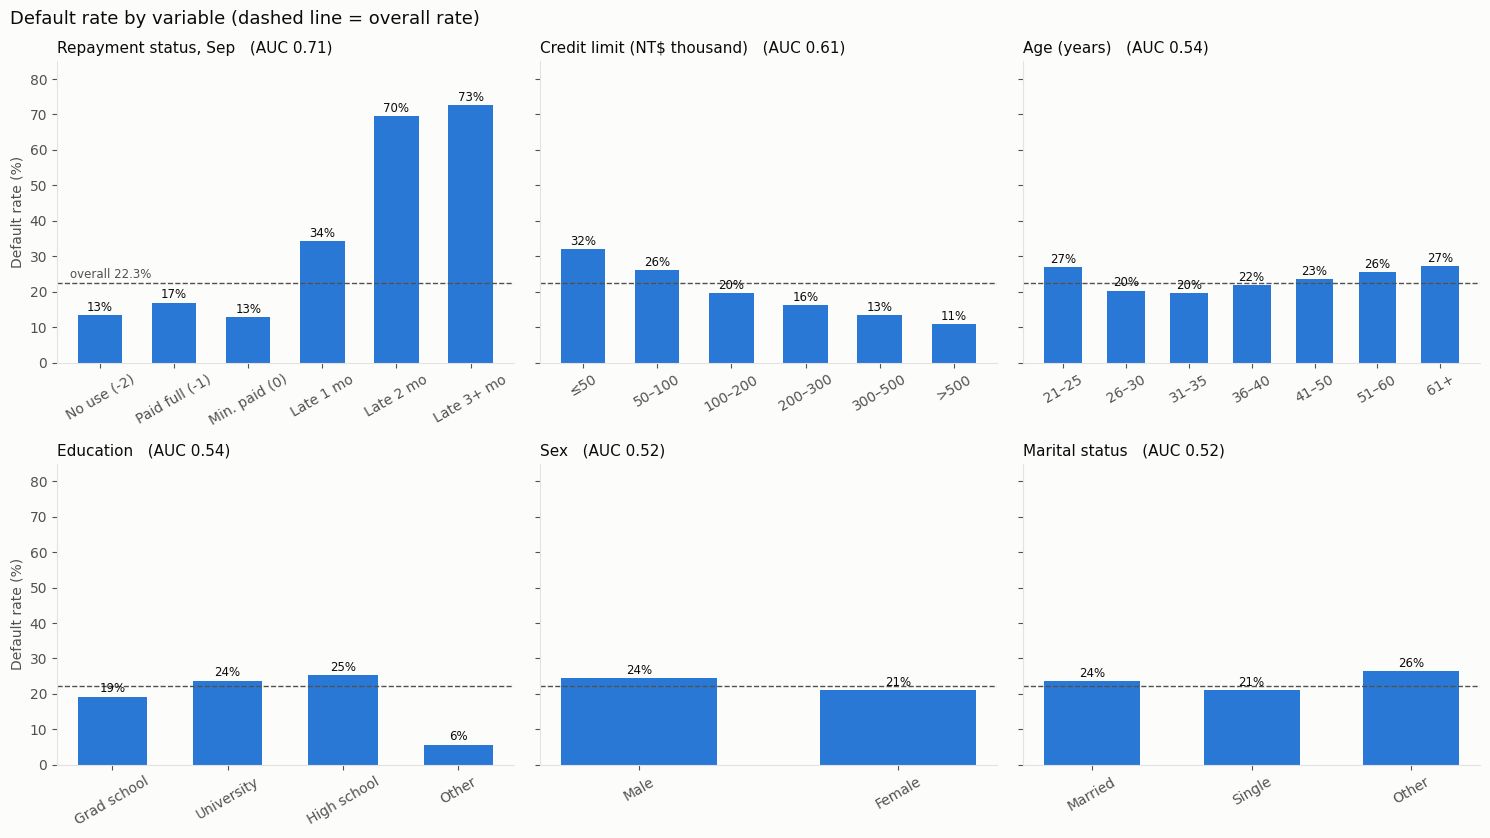

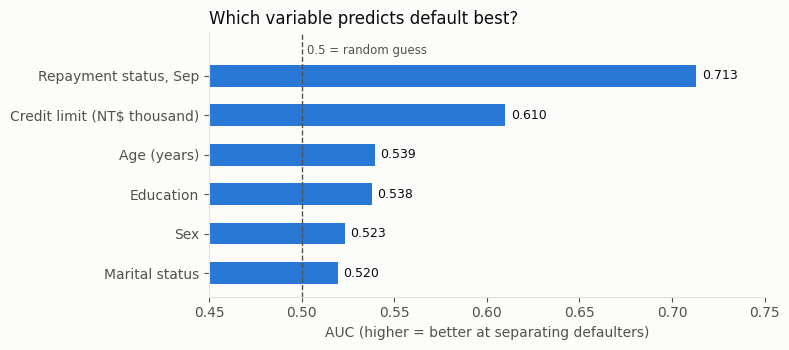

In [3]:
"""
Part 2 — อัตราการผิดนัดชำระหนี้ (Default rate)
รันต่อจาก Part 1 (ใช้ file UCI_Credit_Card_clean.csv)

สิ่งที่สคริปต์นี้ทำ
    1. อัตราผิดนัดชำระโดยรวม
    2. อัตราผิดนัดชำระแยกตามตัวแปร 6 ตัว — สถานะชำระเดือนล่าสุด (PAY_0), วงเงิน, อายุ,
       การศึกษา, เพศ, สถานภาพ — เป็นตาราง + กราฟ
    3. วัดว่าตัวแปรไหนทำนายได้ดีที่สุด ด้วย 2 ตัวชี้วัด
         - ช่วงห่าง = อัตรา default กลุ่มสูงสุด − กลุ่มต่ำสุด (นับเฉพาะกลุ่มที่มี ≥ 100 คน)
         - AUC     = ถ้าใช้ "อัตรา default ของกลุ่มที่ลูกค้าอยู่" เป็นคะแนนทำนาย จะแยกคนผิดนัด
                     ออกจากคนไม่ผิดนัดได้ดีแค่ไหน (0.5 = เดาสุ่ม, 1.0 = แยกได้สมบูรณ์)
"""

import os                                                   # จัดการ path / เดิน folder

import matplotlib.pyplot as plt                             # วาดกราฟ
import pandas as pd                                         # จัดการตารางข้อมูล
from sklearn.metrics import roc_auc_score                   # คำนวณ AUC

# ---------- หา file ข้อมูลที่สะอาดแล้ว ----------
CLEAN_FILE = "UCI_Credit_Card_clean.csv"                    # file ที่ Part 1 บันทึกไว้

if "OUTPUT_PATH" in globals() and os.path.isfile(OUTPUT_PATH):  # ถ้ารัน Part 1 ใน notebook เดียวกันแล้ว
    CLEAN_PATH = OUTPUT_PATH
else:                                                       # ไม่งั้นค้นหา file เอง
    try:
        from google.colab import drive                      # module ของ Colab
        drive.mount("/content/drive", force_remount=False)  # เชื่อม Drive
        roots = ["/content/drive/MyDrive", "/content"]      # จุดเริ่มค้นหา
    except ImportError:                                     # ไม่ได้รันบน Colab
        roots = [os.getcwd()]                               # ค้นหาจาก folder ที่รัน
    CLEAN_PATH = None
    for root in roots:                                      # ไล่ทุกจุดเริ่มค้นหา
        for dirpath, dirnames, filenames in os.walk(root):  # เดินลงทุก folder ย่อย
            dirnames[:] = [d for d in dirnames if not d.startswith(".") and d != "drive"]
            if CLEAN_FILE in filenames:                     # เจอ file
                CLEAN_PATH = os.path.join(dirpath, CLEAN_FILE)
                break
        if CLEAN_PATH:
            break
    assert CLEAN_PATH, f"หา {CLEAN_FILE} ไม่เจอ — รัน Part 1 ก่อน"

df = pd.read_csv(CLEAN_PATH)                                # โหลดข้อมูลที่สะอาดแล้ว
print("ใช้ file:", CLEAN_PATH)

MIN_GROUP = 100                                             # กลุ่มที่เล็กกว่านี้ไม่นับในช่วงห่าง (อัตราแกว่งง่าย)


def show(title, table):                                     # แสดงตาราง: Colab = HTML, นอก notebook = ข้อความ
    print("\n" + "=" * 70 + f"\n{title}\n" + "=" * 70)
    try:
        from IPython import get_ipython
        from IPython.display import display
        if get_ipython() is None:
            raise ImportError
        display(table.style.hide(axis="index").format(precision=2, thousands=","))
    except ImportError:
        print(table.round(2).to_string(index=False))


# ----------------------------------------------------------------------
# 1) อัตราผิดนัดชำระโดยรวม
# ----------------------------------------------------------------------
n = len(df)
n_default = int(df["DEFAULT"].sum())
OVERALL = df["DEFAULT"].mean()                              # อัตราโดยรวม (ใช้เป็นเส้นอ้างอิงในกราฟ)
show("1) อัตราผิดนัดชำระโดยรวม", pd.DataFrame([
    ("ลูกค้าทั้งหมด", f"{n:,}"),
    ("ผิดนัดชำระ", f"{n_default:,}"),
    ("อัตราผิดนัดชำระโดยรวม", f"{OVERALL:.1%}"),
], columns=["รายการ", "ค่า"]))

# ----------------------------------------------------------------------
# 2) จัดกลุ่มแต่ละตัวแปร
#    แต่ละตัวแปรได้คอลัมน์ "กลุ่ม" ที่เรียงลำดับแล้ว (ป้ายเป็นภาษาอังกฤษเพื่อให้กราฟแสดงได้ใน Colab
#    ซึ่งไม่มี font ไทยติดมา)
# ----------------------------------------------------------------------
def pay_group(code):                                        # สถานะชำระ ก.ย. -> กลุ่ม
    if code <= 0:
        return {-2: "No use (-2)", -1: "Paid full (-1)", 0: "Min. paid (0)"}[code]
    return "Late 1 mo" if code == 1 else "Late 2 mo" if code == 2 else "Late 3+ mo"


limit_bins = [0, 50_000, 100_000, 200_000, 300_000, 500_000, 1_000_000]
age_bins = [20, 25, 30, 35, 40, 50, 60, 80]

GROUPS = {  # ชื่อตัวแปร -> (คำอธิบายไทย, ชื่อกราฟ, Series กลุ่มแบบเรียงลำดับ)
    "PAY_0": ("สถานะชำระเดือน ก.ย. (เดือนล่าสุด)", "Repayment status, Sep",
              pd.Categorical(df["PAY_0"].map(pay_group),
                             ["No use (-2)", "Paid full (-1)", "Min. paid (0)",
                              "Late 1 mo", "Late 2 mo", "Late 3+ mo"], ordered=True)),
    "LIMIT_BAL": ("วงเงินบัตร (NT$)", "Credit limit (NT$ thousand)",
                  pd.cut(df["LIMIT_BAL"], limit_bins,
                         labels=["≤50", "50–100", "100–200", "200–300", "300–500", ">500"])),
    "AGE": ("อายุ (ปี)", "Age (years)",
            pd.cut(df["AGE"], age_bins, labels=["21–25", "26–30", "31–35", "36–40", "41–50", "51–60", "61+"])),
    "EDUCATION": ("การศึกษา", "Education",
                  pd.Categorical(df["EDUCATION"].map({1: "Grad school", 2: "University", 3: "High school", 4: "Other"}),
                                 ["Grad school", "University", "High school", "Other"], ordered=True)),
    "SEX": ("เพศ", "Sex",
            pd.Categorical(df["SEX"].map({1: "Male", 2: "Female"}), ["Male", "Female"], ordered=True)),
    "MARRIAGE": ("สถานภาพสมรส", "Marital status",
                 pd.Categorical(df["MARRIAGE"].map({1: "Married", 2: "Single", 3: "Other"}),
                                ["Married", "Single", "Other"], ordered=True)),
}

# ----------------------------------------------------------------------
# 3) อัตราผิดนัดชำระแยกตามกลุ่ม + ตัวชี้วัดความสามารถในการทำนาย
# ----------------------------------------------------------------------
rate_tables = {}                                            # เก็บตารางของแต่ละตัวแปรไว้วาดกราฟ
power_rows = []                                             # เก็บตัวชี้วัดของแต่ละตัวแปร
for var, (thai, _, groups) in GROUPS.items():
    g = df.groupby(groups, observed=True)["DEFAULT"].agg(["count", "mean"])  # จำนวน + อัตรา ต่อกลุ่ม
    t = pd.DataFrame({
        "กลุ่ม": g.index.astype(str),
        "จำนวนคน": g["count"].values,
        "อัตรา default (%)": g["mean"].values * 100,
        "เทียบค่าเฉลี่ย (จุด %)": (g["mean"].values - OVERALL) * 100,  # + = เสี่ยงกว่าค่าเฉลี่ย
    })
    rate_tables[var] = t
    show(f"2) อัตราผิดนัดชำระตาม{thai}  [{var}]", t)

    big = g[g["count"] >= MIN_GROUP]["mean"]                 # เฉพาะกลุ่มที่ใหญ่พอ
    score = pd.Series(groups, index=df.index).map(g["mean"]).astype(float)  # คะแนน = อัตรา default ของกลุ่ม
    power_rows.append({
        "ตัวแปร": var,
        "ความหมาย": thai,
        "กลุ่มเสี่ยงสุด": big.idxmax(),
        "อัตราสูงสุด (%)": big.max() * 100,
        "กลุ่มเสี่ยงต่ำสุด": big.idxmin(),
        "อัตราต่ำสุด (%)": big.min() * 100,
        "ช่วงห่าง (จุด %)": (big.max() - big.min()) * 100,
        "AUC": roc_auc_score(df["DEFAULT"], score),
    })

power = pd.DataFrame(power_rows).sort_values("AUC", ascending=False).reset_index(drop=True)
power.insert(0, "อันดับ", range(1, len(power) + 1))
show("3) ตัวแปรไหนทำนายการผิดนัดได้ดีที่สุด (เรียงตาม AUC)",
     power.assign(AUC=power["AUC"].map("{:.3f}".format)))     # AUC แสดง 3 ตำแหน่ง (ค่าใกล้กันมาก)

best = power.iloc[0]
print(f"\n→ ตัวแปรที่ทำนายได้ดีที่สุด: {best['ตัวแปร']} ({best['ความหมาย']})")
print(f"  อัตรา default ตั้งแต่ {best['อัตราต่ำสุด (%)']:.1f}% ({best['กลุ่มเสี่ยงต่ำสุด']}) "
      f"ถึง {best['อัตราสูงสุด (%)']:.1f}% ({best['กลุ่มเสี่ยงสุด']}), AUC = {best['AUC']:.3f}")
print(f"  อันดับ 2: {power.iloc[1]['ตัวแปร']} AUC = {power.iloc[1]['AUC']:.3f}")

# ----------------------------------------------------------------------
# 4) กราฟ
# ----------------------------------------------------------------------
BAR = "#2a78d6"                                             # สีแท่ง (สีเดียว เพราะทุกกราฟมีชุดข้อมูลเดียว)
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"          # สีตัวอักษร / ตัวอักษรรอง / เส้นอ้างอิง
plt.rcParams.update({"font.size": 10, "axes.edgecolor": GRID, "axes.labelcolor": INK_2,
                     "xtick.color": INK_2, "ytick.color": INK_2, "figure.facecolor": "#fcfcfb",
                     "axes.facecolor": "#fcfcfb"})

# 4.1 อัตรา default ของแต่ละตัวแปร — small multiples 2 x 3, แกน y เดียวกันทุกช่องเพื่อเทียบกันได้
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), sharey=True)
order = list(power["ตัวแปร"])                                # เรียงช่องตามอันดับความสามารถทำนาย
for ax, var in zip(axes.flat, order):
    t = rate_tables[var]
    bars = ax.bar(t["กลุ่ม"], t["อัตรา default (%)"], color=BAR, width=0.6)
    ax.axhline(OVERALL * 100, color=INK_2, linestyle="--", linewidth=1)  # เส้นค่าเฉลี่ยรวม
    for b, v in zip(bars, t["อัตรา default (%)"]):           # ใส่ตัวเลขบนแท่ง
        ax.text(b.get_x() + b.get_width() / 2, v + 1.2, f"{v:.0f}%", ha="center", fontsize=8.5, color=INK)
    auc = power.set_index("ตัวแปร").loc[var, "AUC"]
    ax.set_title(f"{GROUPS[var][1]}   (AUC {auc:.2f})", color=INK, fontsize=11, loc="left")
    ax.tick_params(axis="x", labelrotation=30)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.set_ylim(0, 85)
for ax in axes[:, 0]:
    ax.set_ylabel("Default rate (%)")
axes[0, 0].text(-0.4, OVERALL * 100 + 1.5, f"overall {OVERALL:.1%}", ha="left", fontsize=8.5, color=INK_2)
fig.suptitle("Default rate by variable (dashed line = overall rate)", x=0.01, ha="left",
             fontsize=13, color=INK)
fig.tight_layout()
plt.show()

# 4.2 จัดอันดับตัวแปรตาม AUC
fig, ax = plt.subplots(figsize=(8, 3.6))
p = power.iloc[::-1]                                        # กลับลำดับให้อันดับ 1 อยู่บนสุด
ax.barh([GROUPS[v][1] for v in p["ตัวแปร"]], p["AUC"], color=BAR, height=0.55)
ax.axvline(0.5, color=INK_2, linestyle="--", linewidth=1)   # 0.5 = เดาสุ่ม
ax.text(0.503, len(p) - 0.45, "0.5 = random guess", fontsize=8.5, color=INK_2)
for y, v in enumerate(p["AUC"]):
    ax.text(v + 0.003, y, f"{v:.3f}", va="center", fontsize=9, color=INK)
ax.set_xlim(0.45, 0.75)
ax.set_ylim(-0.6, len(p) + 0.1)                              # เว้นที่ด้านบนให้ป้าย 0.5
ax.set_xlabel("AUC (higher = better at separating defaulters)")
ax.set_title("Which variable predicts default best?", loc="left", color=INK, fontsize=12)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()


In [4]:
"""
Part 2 — อัตราการผิดนัดชำระหนี้ + สรุปผลเป็นข้อความ (cell เดียวจบ)
ต้องการแค่ file UCI_Credit_Card_clean.csv จาก Part 1
"""

import os                                                      # จัดการ path / เดิน folder

import pandas as pd                                            # จัดการตาราง
from sklearn.metrics import roc_auc_score                      # วัดความแม่นในการทำนาย

# ---------- 0) หา file ข้อมูลที่คลีนแล้ว ----------
CLEAN_FILE = "UCI_Credit_Card_clean.csv"                       # file ที่ Part 1 บันทึกไว้
if "OUTPUT_PATH" in globals() and os.path.isfile(OUTPUT_PATH): # รัน Part 1 แล้ว -> ใช้ path เดิม
    CLEAN_PATH = OUTPUT_PATH
else:                                                          # ยังไม่ได้รัน -> ค้นหา file ใน Drive
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        roots = ["/content/drive/MyDrive", "/content"]
    except ImportError:
        roots = [os.getcwd()]
    CLEAN_PATH = next((os.path.join(d, CLEAN_FILE)
                       for r in roots if os.path.isdir(r)
                       for d, _, files in os.walk(r) if CLEAN_FILE in files), None)
    assert CLEAN_PATH, f"หา {CLEAN_FILE} ไม่เจอ — รัน Part 1 ก่อน"

df = pd.read_csv(CLEAN_PATH)                                   # ข้อมูลที่คลีนแล้ว
print("ใช้ file:", CLEAN_PATH)

# ---------- 1) อัตราผิดนัดชำระโดยรวม ----------
total = len(df)                                                # จำนวนลูกค้าทั้งหมด
defaults = df["DEFAULT"].sum()                                 # จำนวนคนผิดนัด (DEFAULT = 1)
overall = defaults / total                                     # อัตรา = ผิดนัด ÷ ทั้งหมด
print(f"อัตราผิดนัดโดยรวม = {defaults:,} ÷ {total:,} = {overall:.2%}")

# ---------- 2) จัดกลุ่มตัวแปร ----------
df["สถานะชำระ_กย"] = pd.cut(df["PAY_0"], [-3, 0, 1, 2, 9],
                            labels=["ไม่ค้าง (-2,-1,0)", "ค้าง 1 เดือน", "ค้าง 2 เดือน", "ค้าง 3+ เดือน"])
df["กลุ่มวงเงิน"] = pd.cut(df["LIMIT_BAL"], [0, 50_000, 100_000, 200_000, 500_000, 1_000_000],
                          labels=["≤50k", "50k-100k", "100k-200k", "200k-500k", ">500k"])
df["กลุ่มอายุ"] = pd.cut(df["AGE"], [20, 30, 40, 50, 80], labels=["21-30", "31-40", "41-50", "51+"])
df["การศึกษา"] = df["EDUCATION"].map({1: "บัณฑิตวิทยาลัย", 2: "มหาวิทยาลัย", 3: "ม.ปลาย", 4: "อื่น ๆ"})
df["เพศ"] = df["SEX"].map({1: "ชาย", 2: "หญิง"})

VARIABLES = ["สถานะชำระ_กย", "กลุ่มวงเงิน", "กลุ่มอายุ", "การศึกษา", "เพศ"]

# ---------- 3) อัตราผิดนัดของแต่ละกลุ่ม ----------
results = []
for var in VARIABLES:
    t = df.groupby(var, observed=True)["DEFAULT"].agg(["count", "sum"])      # นับคน + นับคนผิดนัด
    t.columns = ["จำนวนคน", "ผิดนัด"]
    t["อัตราผิดนัด (%)"] = (t["ผิดนัด"] / t["จำนวนคน"] * 100).round(1)     # ผิดนัด ÷ จำนวนคน
    t["ต่างจากค่าเฉลี่ย (จุด%)"] = (t["อัตราผิดนัด (%)"] - overall * 100).round(1)
    print(f"\n=== อัตราผิดนัดตาม {var} ===")
    print(t.to_string())

    score = df[var].map(t["อัตราผิดนัด (%)"]).astype(float)                 # คะแนน = อัตราของกลุ่มที่อยู่
    results.append({"ตัวแปร": var,
                    "ต่ำสุด (%)": t["อัตราผิดนัด (%)"].min(),
                    "สูงสุด (%)": t["อัตราผิดนัด (%)"].max(),
                    "ช่วงห่าง (จุด%)": round(t["อัตราผิดนัด (%)"].max() - t["อัตราผิดนัด (%)"].min(), 1),
                    "AUC": round(roc_auc_score(df["DEFAULT"], score), 3)})

# ---------- 4) ตัวแปรไหนทำนายได้ดีที่สุด ----------
summary = pd.DataFrame(results).sort_values("AUC", ascending=False)
print("\n=== เปรียบเทียบความสามารถในการทำนาย (AUC: 0.5 = เดาสุ่ม, 1 = สมบูรณ์) ===")
print(summary.to_string(index=False))

# ---------- 5) สรุปผลเป็นข้อความ ----------
# คำอธิบายแนวโน้ม (ใช้เมื่ออัตราเพิ่ม/ลดตามลำดับกลุ่มจริง ๆ เท่านั้น)
TREND_TEXT = {
    "สถานะชำระ_กย": "ยิ่งค้างนาน ยิ่งผิดนัดมาก",
    "กลุ่มวงเงิน": "ยิ่งวงเงินสูง ยิ่งผิดนัดน้อย",
    "กลุ่มอายุ": "ยิ่งอายุมาก ยิ่งผิดนัดมาก",
}

print("\n=== สรุปผล ===")
print(f"* ค่าเฉลี่ยรวม: {overall:.1%}")
for var in VARIABLES:
    t = df.groupby(var, observed=True)["DEFAULT"].mean() * 100   # อัตราผิดนัดของแต่ละกลุ่ม (%)
    gap = t.max() - t.min()                                       # ช่วงห่าง (จุด %)
    name = var.replace("_กย", " ก.ย.")                             # ชื่อตัวแปรสำหรับแสดงผล
    lo = str(t.idxmin()).split(" (")[0]                           # กลุ่มต่ำสุด (ตัดรหัสในวงเล็บออก)
    hi = str(t.idxmax()).split(" (")[0]                           # กลุ่มสูงสุด
    monotonic = t.is_monotonic_increasing or t.is_monotonic_decreasing  # อัตราเพิ่ม/ลดตามลำดับกลุ่ม

    if var in TREND_TEXT and monotonic:                           # มีแนวโน้มชัดเจน -> บอกแนวโน้ม
        note = TREND_TEXT[var]
    elif gap < 10:                                                # ช่วงห่างน้อย -> แทบไม่ต่าง
        note = "แทบไม่ต่างจากค่าเฉลี่ย"
    else:                                                         # ต่างกันแต่ไม่เป็นแนวโน้ม
        note = "ต่างกันพอสมควร แต่ไม่เป็นแนวโน้มชัดเจน"

    if gap >= 10:
        line = f"อัตราเปลี่ยนจาก {t.min():.1f}% ({lo}) ขึ้นไปถึง {t.max():.1f}% ({hi})"
    else:
        line = f"อัตราเปลี่ยนแค่ {t.min():.1f}% ({lo}) กับ {t.max():.1f}% ({hi})"
    print(f"* เมื่อแยกตาม{name}: {line} {note}")

best = summary.iloc[0]
print(f"\n→ ตัวแปรที่ทำนายได้ดีที่สุด: {best['ตัวแปร'].replace('_กย', ' ก.ย.')} "
      f"(AUC = {best['AUC']}, ช่วงห่าง {best['ช่วงห่าง (จุด%)']} จุด)")


ใช้ file: /content/drive/MyDrive/Model ผิดชำระหนี้/UCI_Credit_Card_clean.csv
อัตราผิดนัดโดยรวม = 6,605 ÷ 29,601 = 22.31%

=== อัตราผิดนัดตาม สถานะชำระ_กย ===
                   จำนวนคน  ผิดนัด  อัตราผิดนัด (%)  ต่างจากค่าเฉลี่ย (จุด%)
สถานะชำระ_กย                                                                
ไม่ค้าง (-2,-1,0)    22840    3184             13.9                     -8.4
ค้าง 1 เดือน          3662    1251             34.2                     11.9
ค้าง 2 เดือน          2640    1837             69.6                     47.3
ค้าง 3+ เดือน          459     333             72.5                     50.2

=== อัตราผิดนัดตาม กลุ่มวงเงิน ===
             จำนวนคน  ผิดนัด  อัตราผิดนัด (%)  ต่างจากค่าเฉลี่ย (จุด%)
กลุ่มวงเงิน                                                           
≤50k            7585    2430             32.0                      9.7
50k-100k        4763    1239             26.0                      3.7
100k-200k       7747    1524             19.7               

In [5]:
"""
Part 3 — สร้างคุณลักษณะ (Feature engineering) จากข้อมูลย้อนหลัง 6 เดือน (เม.ย.–ก.ย. 2005)
ต้องการแค่ file UCI_Credit_Card_clean.csv จาก Part 1 (cell เดียวจบ)

คุณลักษณะที่สร้าง (5 ตัว)
    1. AVG_UTIL       อัตราการใช้วงเงินเฉลี่ย 6 เดือน       = เฉลี่ย(ยอดบิล ÷ วงเงิน)
    2. PAY_RATIO      อัตราส่วนการชำระต่อบิล                 = ยอดจ่ายรวม ÷ ยอดบิลรวม (จับคู่เดือนให้ถูก)
    3. MAX_DELAY      การค้างชำระที่ร้ายแรงที่สุด             = จำนวนเดือนที่ค้างมากที่สุดใน 6 เดือน
    4. N_LATE_MONTHS  จำนวนเดือนที่ค้างชำระ                  = นับเดือนที่ค้าง (0–6)
    5. UTIL_TREND     แนวโน้มการใช้วงเงิน                    = ความชันของอัตราการใช้วงเงินตามเวลา (ต่อเดือน)
"""

import os                                                      # จัดการ path / เดิน folder

import numpy as np                                             # คำนวณตัวเลข
import pandas as pd                                            # จัดการตาราง
from sklearn.metrics import roc_auc_score                      # วัดความสามารถในการทำนาย

# ---------- 0) หา file ข้อมูลที่คลีนแล้ว ----------
CLEAN_FILE = "UCI_Credit_Card_clean.csv"                       # file ที่ Part 1 บันทึกไว้
if "OUTPUT_PATH" in globals() and os.path.isfile(OUTPUT_PATH): # รัน Part 1 แล้ว -> ใช้ path เดิม
    CLEAN_PATH = OUTPUT_PATH
else:                                                          # ยังไม่ได้รัน -> ค้นหา file ใน Drive
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        roots = ["/content/drive/MyDrive", "/content"]
    except ImportError:
        roots = [os.getcwd()]
    CLEAN_PATH = next((os.path.join(d, CLEAN_FILE)
                       for r in roots if os.path.isdir(r)
                       for d, _, files in os.walk(r) if CLEAN_FILE in files), None)
    assert CLEAN_PATH, f"หา {CLEAN_FILE} ไม่เจอ — รัน Part 1 ก่อน"

df = pd.read_csv(CLEAN_PATH)                                   # ข้อมูลที่คลีนแล้ว
print("ใช้ file:", CLEAN_PATH)

# เลข 1..6 = ก.ย. ... เม.ย. (1 = เดือนล่าสุด)
BILL = [f"BILL_AMT{i}" for i in range(1, 7)]                   # ยอดบิล 6 เดือน
PAID = [f"PAY_AMT{i}" for i in range(1, 7)]                    # ยอดจ่าย 6 เดือน
DELAY = [f"DELAY_{i}" for i in range(1, 7)]                    # จำนวนเดือนที่ค้าง (สร้างไว้ใน Part 1)

# ----------------------------------------------------------------------
# 1) AVG_UTIL — อัตราการใช้วงเงินเฉลี่ย
#    ยอดบิล ÷ วงเงิน ของแต่ละเดือน แล้วเฉลี่ย 6 เดือน
#    บิลติดลบ (จ่ายเกิน) นับเป็น 0 เพราะไม่ได้ใช้วงเงิน
# ----------------------------------------------------------------------
util = df[BILL].clip(lower=0).div(df["LIMIT_BAL"], axis=0)     # อัตราการใช้วงเงินรายเดือน
df["AVG_UTIL"] = util.mean(axis=1)

# ----------------------------------------------------------------------
# 2) PAY_RATIO — อัตราส่วนการชำระต่อบิล
#    เงินที่จ่ายในเดือนหนึ่งคือการจ่ายบิลของเดือนก่อนหน้า
#    เช่น PAY_AMT1 (จ่ายใน ก.ย.) จ่ายบิล BILL_AMT2 (ส.ค.) จึงจับคู่ PAY_AMT1..5 กับ BILL_AMT2..6
#    - ถ้าไม่มียอดบิลเลย (รวม ≤ 0) = ไม่มีหนี้ต้องจ่าย -> ให้ค่า 1 (จ่ายครบ)
#    - ตัดค่าไว้ที่ 0–1 (จ่ายเกินบิลก็นับว่าจ่ายครบ 100%)
# ----------------------------------------------------------------------
paid_total = df[PAID[:5]].sum(axis=1)                          # จ่ายรวม ก.ย.–พ.ค.
bill_total = df[BILL[1:]].clip(lower=0).sum(axis=1)            # บิลรวม ส.ค.–เม.ย.
df["PAY_RATIO"] = np.where(bill_total > 0, paid_total / bill_total.replace(0, np.nan), 1.0)
df["PAY_RATIO"] = df["PAY_RATIO"].clip(0, 1)

# ----------------------------------------------------------------------
# 3) MAX_DELAY — การค้างชำระที่ร้ายแรงที่สุดใน 6 เดือน (0 = ไม่เคยค้าง)
# 4) N_LATE_MONTHS — จำนวนเดือนที่ค้างชำระ (0–6)
# ----------------------------------------------------------------------
df["MAX_DELAY"] = df[DELAY].max(axis=1)
df["N_LATE_MONTHS"] = (df[DELAY] > 0).sum(axis=1)

# ----------------------------------------------------------------------
# 5) UTIL_TREND — แนวโน้มการใช้วงเงิน
#    ความชัน (slope) ของเส้นตรงที่ลากผ่านอัตราการใช้วงเงิน เม.ย. -> ก.ย.
#    + = ใช้วงเงินเพิ่มขึ้นเรื่อย ๆ (หนี้พอกขึ้น), − = ใช้ลดลง (กำลังผ่อนหนี้)
#    หน่วย: จุด % ของวงเงินต่อเดือน
# ----------------------------------------------------------------------
u = util[BILL[::-1]].to_numpy() * 100                          # เรียงจากเก่า (เม.ย.) ไปใหม่ (ก.ย.)
x = np.arange(6) - 2.5                                         # เดือนที่ 0..5 ลบค่าเฉลี่ย
df["UTIL_TREND"] = (u * x).sum(axis=1) / (x ** 2).sum()        # สูตรความชันของ least squares

FEATURES = {  # ชื่อ -> คำอธิบาย
    "AVG_UTIL": "อัตราการใช้วงเงินเฉลี่ย",
    "PAY_RATIO": "อัตราส่วนการชำระต่อบิล",
    "MAX_DELAY": "การค้างชำระที่ร้ายแรงที่สุด (เดือน)",
    "N_LATE_MONTHS": "จำนวนเดือนที่ค้างชำระ",
    "UTIL_TREND": "แนวโน้มการใช้วงเงิน (จุด%/เดือน)",
}

# ----------------------------------------------------------------------
# 6) สถิติพื้นฐานของแต่ละคุณลักษณะ
# ----------------------------------------------------------------------
desc = df[list(FEATURES)].describe().T
stats = pd.DataFrame({
    "คุณลักษณะ": list(FEATURES),
    "ความหมาย": list(FEATURES.values()),
    "mean": desc["mean"].values,
    "median": desc["50%"].values,
    "min": desc["min"].values,
    "max": desc["max"].values,
}).round(3)
print("\n=== 1) สถิติพื้นฐานของคุณลักษณะใหม่ ===")
print(stats.to_string(index=False))

# ----------------------------------------------------------------------
# 7) อัตราผิดนัดชำระตามกลุ่มของแต่ละคุณลักษณะ
# ----------------------------------------------------------------------
GROUPS = {
    "AVG_UTIL": pd.cut(df["AVG_UTIL"], [-0.01, 0.1, 0.3, 0.5, 0.8, np.inf],
                       labels=["<10%", "10-30%", "30-50%", "50-80%", "≥80%"]),
    "PAY_RATIO": pd.cut(df["PAY_RATIO"], [-0.01, 0.05, 0.2, 0.5, 0.99, 1.0],
                        labels=["<5%", "5-20%", "20-50%", "50-99%", "จ่ายครบ 100%"]),
    "MAX_DELAY": pd.cut(df["MAX_DELAY"], [-1, 0, 1, 2, 9],
                        labels=["ไม่เคยค้าง", "ค้างสูงสุด 1 เดือน", "ค้างสูงสุด 2 เดือน", "ค้างสูงสุด 3+ เดือน"]),
    "N_LATE_MONTHS": pd.cut(df["N_LATE_MONTHS"], [-1, 0, 1, 3, 6],
                            labels=["0 เดือน", "1 เดือน", "2-3 เดือน", "4-6 เดือน"]),
    "UTIL_TREND": pd.cut(df["UTIL_TREND"], [-np.inf, -2, -0.5, 0.5, 2, np.inf],
                         labels=["ลดลงมาก", "ลดลง", "คงที่", "เพิ่มขึ้น", "เพิ่มขึ้นมาก"]),
}

overall = df["DEFAULT"].mean() * 100                           # อัตราผิดนัดโดยรวม (%)
print(f"\nอัตราผิดนัดโดยรวม = {overall:.1f}%")
results = []
for feat, groups in GROUPS.items():
    t = df.groupby(groups, observed=True)["DEFAULT"].agg(["count", "sum"])
    t.columns = ["จำนวนคน", "ผิดนัด"]
    t["อัตราผิดนัด (%)"] = (t["ผิดนัด"] / t["จำนวนคน"] * 100).round(1)
    t["ต่างจากค่าเฉลี่ย (จุด%)"] = (t["อัตราผิดนัด (%)"] - overall).round(1)
    print(f"\n=== 2) อัตราผิดนัดตาม {feat} — {FEATURES[feat]} ===")
    print(t.to_string())

    auc = roc_auc_score(df["DEFAULT"], df[feat])               # AUC จากค่าตัวเลขตรง ๆ
    results.append({"คุณลักษณะ": feat, "ความหมาย": FEATURES[feat],
                    "ต่ำสุด (%)": t["อัตราผิดนัด (%)"].min(), "สูงสุด (%)": t["อัตราผิดนัด (%)"].max(),
                    "AUC": round(max(auc, 1 - auc), 3),        # กลับทิศถ้าค่าน้อย = เสี่ยงมาก
                    "ทิศทาง": "ค่ามาก = เสี่ยงมาก" if auc >= 0.5 else "ค่ามาก = เสี่ยงน้อย"})

# ----------------------------------------------------------------------
# 8) เทียบความสามารถในการทำนายกับ PAY_0 (ตัวที่ดีที่สุดใน Part 2)
# ----------------------------------------------------------------------
base = roc_auc_score(df["DEFAULT"], df["PAY_0"])
# (ใช้ค่าตัวเลขตรง ๆ เหมือนคุณลักษณะอื่น จึงได้ 0.690 ต่างจาก 0.700 ใน Part 2 ที่ใช้แบบจัดกลุ่ม)
results.append({"คุณลักษณะ": "PAY_0 (เทียบ)", "ความหมาย": "สถานะชำระเดือน ก.ย. อย่างเดียว",
                "ต่ำสุด (%)": np.nan, "สูงสุด (%)": np.nan, "AUC": round(base, 3), "ทิศทาง": "ค่ามาก = เสี่ยงมาก"})
summary = pd.DataFrame(results).sort_values("AUC", ascending=False)
print("\n=== 3) เปรียบเทียบความสามารถในการทำนาย (AUC: 0.5 = เดาสุ่ม, 1 = สมบูรณ์) ===")
print(summary.to_string(index=False))

# ----------------------------------------------------------------------
# 9) สรุปผลเป็นข้อความ + บันทึก file
# ----------------------------------------------------------------------
print("\n=== สรุปผล ===")
for feat, groups in GROUPS.items():
    t = df.groupby(groups, observed=True)["DEFAULT"].mean() * 100
    print(f"* {FEATURES[feat]} ({feat}): อัตราผิดนัดตั้งแต่ {t.min():.1f}% ({t.idxmin()}) "
          f"ถึง {t.max():.1f}% ({t.idxmax()})")
best = summary.iloc[0]
print(f"\n→ คุณลักษณะที่ทำนายได้ดีที่สุด: {best['คุณลักษณะ']} ({best['ความหมาย']}) AUC = {best['AUC']}")

FEATURE_PATH = os.path.join(os.path.dirname(CLEAN_PATH), "UCI_Credit_Card_features.csv")
df.to_csv(FEATURE_PATH, index=False)                           # เก็บไว้ใช้ทำโมเดลใน part ถัดไป
print(f"\nบันทึกไฟล์: {FEATURE_PATH}  ({df.shape[0]:,} แถว, {df.shape[1]} คอลัมน์)")


ใช้ file: /content/drive/MyDrive/Model ผิดชำระหนี้/UCI_Credit_Card_clean.csv

=== 1) สถิติพื้นฐานของคุณลักษณะใหม่ ===
    คุณลักษณะ                            ความหมาย  mean  median     min     max
     AVG_UTIL             อัตราการใช้วงเงินเฉลี่ย 0.373   0.284   0.000   5.364
    PAY_RATIO              อัตราส่วนการชำระต่อบิล 0.387   0.123   0.000   1.000
    MAX_DELAY การค้างชำระที่ร้ายแรงที่สุด (เดือน) 0.687   0.000   0.000   8.000
N_LATE_MONTHS               จำนวนเดือนที่ค้างชำระ 0.841   0.000   0.000   6.000
   UTIL_TREND    แนวโน้มการใช้วงเงิน (จุด%/เดือน) 2.220   0.143 -46.258 116.682

อัตราผิดนัดโดยรวม = 22.3%

=== 2) อัตราผิดนัดตาม AVG_UTIL — อัตราการใช้วงเงินเฉลี่ย ===
          จำนวนคน  ผิดนัด  อัตราผิดนัด (%)  ต่างจากค่าเฉลี่ย (จุด%)
AVG_UTIL                                                           
<10%        10912    2069             19.0                     -3.3
10-30%       4167     655             15.7                     -6.6
30-50%       3622     751             20.

In [6]:
"""
Part 4 — คัดเลือกตัวแปรด้วย Weight of Evidence (WoE) และ Information Value (IV)
ต้องการ file UCI_Credit_Card_features.csv จาก Part 3 (cell เดียวจบ)

ขั้นตอน
    1. แบ่งแต่ละตัวแปรเป็นช่วง (Bin)
    2. คำนวณ WoE ของแต่ละ Bin และ IV ของแต่ละตัวแปร แล้วจัดอันดับ (Rank)
    3. คัดตัวแปรออกตาม 3 กฎ
         กฎ 1: IV < 0.02                 -> ตัด (แทบไม่มีพลังทำนาย)
         กฎ 2: ข้อมูลซ้ำกับตัวแปรอื่น        -> ตัด (DELAY_i คือ PAY_i ที่ตัดค่าติดลบออก)
         กฎ 3: สหสัมพันธ์ของ WoE > 0.7    -> ตัวที่ IV ต่ำกว่าถูกตัด (ข้อมูลซ้ำซ้อน)
    4. สรุปตัวแปรที่เก็บ / ตัด พร้อมเหตุผล

สูตร (Good = ไม่ผิดนัด, Bad = ผิดนัด)
    %Good_i = จำนวน Good ใน Bin i ÷ Good ทั้งหมด
    %Bad_i  = จำนวน Bad  ใน Bin i ÷ Bad  ทั้งหมด
    WoE_i   = ln(%Good_i ÷ %Bad_i)           (+ = ปลอดภัยกว่าเฉลี่ย, − = เสี่ยงกว่าเฉลี่ย)
    IV      = Σ (%Good_i − %Bad_i) × WoE_i

เกณฑ์ IV (Siddiqi, 2006)
    < 0.02 ไม่มีประโยชน์ | 0.02–0.1 อ่อน | 0.1–0.3 ปานกลาง | 0.3–0.5 แรง | > 0.5 แรงมาก (ตรวจว่ารั่วไหมก่อนใช้)
"""

import os                                                      # จัดการ path / เดิน folder

import numpy as np                                             # คำนวณตัวเลข
import pandas as pd                                            # จัดการตาราง

# ---------- 0) หา file ข้อมูลจาก Part 3 ----------
FEATURE_FILE = "UCI_Credit_Card_features.csv"                  # file ที่ Part 3 บันทึกไว้
if "FEATURE_PATH" in globals() and os.path.isfile(FEATURE_PATH):   # รัน Part 3 แล้ว -> ใช้ path เดิม
    DATA_PATH = FEATURE_PATH
else:                                                          # ยังไม่ได้รัน -> ค้นหา file ใน Drive
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        roots = ["/content/drive/MyDrive", "/content"]
    except ImportError:
        roots = [os.getcwd()]
    DATA_PATH = next((os.path.join(d, FEATURE_FILE)
                      for r in roots if os.path.isdir(r)
                      for d, _, files in os.walk(r) if FEATURE_FILE in files), None)
    assert DATA_PATH, f"หา {FEATURE_FILE} ไม่เจอ — รัน Part 3 ก่อน"

df = pd.read_csv(DATA_PATH)
y = df["DEFAULT"]                                              # 1 = Bad (ผิดนัด), 0 = Good
print("ใช้ file:", DATA_PATH)
print(f"Good = {(y == 0).sum():,}  Bad = {(y == 1).sum():,}")

# ตัวแปรที่ไม่ใช่ตัวทำนาย: ID (รหัส), DEFAULT (คำตอบ)
CANDIDATES = [c for c in df.columns if c not in ("ID", "DEFAULT")]

PAY_STATUS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]  # สถานะชำระ: รหัส -2..8 (ชื่อตามต้นฉบับ)
DELAY_COLS = [f"DELAY_{i}" for i in range(1, 7)]               # จำนวนเดือนที่ค้าง: 0..8


# ----------------------------------------------------------------------
# 1) แบ่ง Bin
#    - สถานะชำระ / จำนวนเดือนค้าง: ใช้ค่าจริง ค่า ≥ 3 รวมเป็น "3+" (คนน้อย WoE แกว่ง)
#    - ตัวแปรหมวดหมู่ (ค่าไม่ซ้ำ ≤ 10): ใช้ค่าจริงเป็น Bin
#    - ตัวแปรต่อเนื่อง: แบ่ง 10 ช่วงเท่า ๆ กันตามจำนวนคน (decile)
# ----------------------------------------------------------------------
def make_bins(s, name):
    if name in PAY_STATUS or name in DELAY_COLS or name in ("MAX_DELAY",):
        return s.clip(upper=3).map(lambda v: "3+" if v >= 3 else str(int(v)))
    if s.nunique() <= 10:
        return s.astype(int).astype(str)
    return pd.qcut(s, 10, duplicates="drop").astype(str)


# ----------------------------------------------------------------------
# 2) คำนวณ WoE ต่อ Bin และ IV ต่อตัวแปร
#    บวก 0.5 ให้ทุกช่อง กัน log(0) ในกรณี Bin ไม่มี Good หรือ Bad เลย
# ----------------------------------------------------------------------
def woe_table(s, name):
    b = make_bins(s, name)
    order = s.groupby(b).min().sort_values().index             # เรียง Bin ตามค่าจริง (ไม่ใช่ตามตัวอักษร)
    t = pd.crosstab(b, y).reindex(index=order, columns=[0, 1], fill_value=0)
    t.columns = ["Good", "Bad"]
    t["จำนวน"] = t["Good"] + t["Bad"]
    t["อัตราผิดนัด (%)"] = t["Bad"] / t["จำนวน"] * 100
    pct_good = (t["Good"] + 0.5) / (t["Good"].sum() + 0.5 * len(t))
    pct_bad = (t["Bad"] + 0.5) / (t["Bad"].sum() + 0.5 * len(t))
    t["WoE"] = np.log(pct_good / pct_bad)
    t["IV ของ Bin"] = (pct_good - pct_bad) * t["WoE"]
    t = t.reset_index().rename(columns={"row_0": "Bin", t.index.name or "index": "Bin"})
    t.insert(0, "ตัวแปร", name)
    return t[["ตัวแปร", "Bin", "จำนวน", "Good", "Bad", "อัตราผิดนัด (%)", "WoE", "IV ของ Bin"]], b


def strength(iv):
    if iv < 0.02:
        return "ไม่มีประโยชน์"
    if iv < 0.1:
        return "อ่อน"
    if iv < 0.3:
        return "ปานกลาง"
    if iv < 0.5:
        return "แรง"
    return "แรงมาก"


woe_tables, woe_values, iv_rows = {}, {}, []
for col in CANDIDATES:
    t, bins = woe_table(df[col], col)
    woe_tables[col] = t
    woe_values[col] = bins.map(t.set_index("Bin")["WoE"])      # ค่า WoE ของแต่ละคน (ใช้หาสหสัมพันธ์)
    iv = t["IV ของ Bin"].sum()
    iv_rows.append({"ตัวแปร": col, "จำนวน Bin": len(t), "IV": iv, "ระดับ": strength(iv)})

iv_table = pd.DataFrame(iv_rows).sort_values("IV", ascending=False).reset_index(drop=True)
iv_table.insert(0, "Rank", range(1, len(iv_table) + 1))
print("\n=== 1) Information Value ของทุกตัวแปร (เรียงตาม Rank) ===")
print(iv_table.round(4).to_string(index=False))

# ----------------------------------------------------------------------
# 3) คัดเลือกตัวแปร
# ----------------------------------------------------------------------
decision = {}                                                  # ตัวแปร -> (ผล, เหตุผล)

# กฎ 1: IV < 0.02
for _, r in iv_table.iterrows():
    if r["IV"] < 0.02:
        decision[r["ตัวแปร"]] = ("ตัด", f"IV = {r['IV']:.4f} < 0.02 แทบไม่มีพลังทำนาย")

# กฎ 2: DELAY_i คือ PAY_x ของเดือนเดียวกันที่ตัดค่าติดลบเป็น 0 -> ข้อมูลซ้ำ เก็บ PAY_x ไว้เพราะละเอียดกว่า
for i, pay in enumerate(PAY_STATUS, start=1):
    decision.setdefault(f"DELAY_{i}", ("ตัด", f"ซ้ำกับ {pay} (สร้างมาจาก {pay}) และ IV ต่ำกว่า"))

# กฎ 3: ไล่จาก IV สูงไปต่ำ ถ้าสหสัมพันธ์ของ WoE กับตัวที่เก็บแล้ว > 0.7 -> ตัด
CORR_LIMIT = 0.7
kept = []
for col in iv_table["ตัวแปร"]:
    if col in decision:
        continue
    corr = {k: abs(np.corrcoef(woe_values[col], woe_values[k])[0, 1]) for k in kept}
    worst = max(corr, key=corr.get) if corr else None
    if worst and corr[worst] > CORR_LIMIT:
        decision[col] = ("ตัด", f"สหสัมพันธ์กับ {worst} = {corr[worst]:.2f} > {CORR_LIMIT} (ซ้ำซ้อน, IV ต่ำกว่า)")
    else:
        kept.append(col)
        decision[col] = ("เก็บ", f"IV = {iv_table.set_index('ตัวแปร').loc[col, 'IV']:.3f} "
                                 f"({strength(iv_table.set_index('ตัวแปร').loc[col, 'IV'])}) และไม่ซ้ำกับตัวอื่น")

result = iv_table.assign(
    ผล=iv_table["ตัวแปร"].map(lambda c: decision[c][0]),
    เหตุผล=iv_table["ตัวแปร"].map(lambda c: decision[c][1]),
)
print("\n=== 2) ผลการคัดเลือกตัวแปร ===")
print(result[["Rank", "ตัวแปร", "IV", "ระดับ", "ผล", "เหตุผล"]].round(4).to_string(index=False))

# ----------------------------------------------------------------------
# 4) ตาราง WoE ของตัวแปรที่เก็บไว้ (ตัวแปร / Bin / WoE)
# ----------------------------------------------------------------------
print("\n=== 3) ตาราง WoE ของตัวแปรที่เก็บไว้ ===")
for col in kept:
    t = woe_tables[col]
    print(f"\n--- {col}  (IV = {t['IV ของ Bin'].sum():.3f}) ---")
    print(t.drop(columns="ตัวแปร").round(3).to_string(index=False))

# ----------------------------------------------------------------------
# 5) สรุป + บันทึก
# ----------------------------------------------------------------------
dropped = [c for c in iv_table["ตัวแปร"] if decision[c][0] == "ตัด"]
print("\n=== สรุป ===")
print(f"* เก็บ {len(kept)} ตัวแปร: {', '.join(kept)}")
print(f"* ตัด {len(dropped)} ตัวแปร: {', '.join(dropped)}")
strong = iv_table[iv_table["IV"] > 0.5]["ตัวแปร"].tolist()
print(f"* IV > 0.5 (แรงมาก): {', '.join(strong)} — ตรวจแล้วไม่ใช่ข้อมูลรั่ว เพราะเป็นประวัติก่อนเดือนที่วัดผล")

out_dir = os.path.dirname(DATA_PATH)
pd.concat(woe_tables.values()).to_csv(os.path.join(out_dir, "woe_table.csv"), index=False)
result.to_csv(os.path.join(out_dir, "iv_selection.csv"), index=False)
print(f"\nบันทึก: woe_table.csv, iv_selection.csv ใน {out_dir}")


ใช้ file: /content/drive/MyDrive/Model ผิดชำระหนี้/UCI_Credit_Card_features.csv
Good = 22,996  Bad = 6,605

=== 1) Information Value ของทุกตัวแปร (เรียงตาม Rank) ===
 Rank             ตัวแปร  จำนวน Bin     IV         ระดับ
    1              PAY_0          6 0.8803        แรงมาก
    2            DELAY_1          4 0.8677        แรงมาก
    3      N_LATE_MONTHS          7 0.8628        แรงมาก
    4          MAX_DELAY          4 0.7737        แรงมาก
    5              PAY_2          6 0.5487        แรงมาก
    6            DELAY_2          4 0.5458        แรงมาก
    7              PAY_3          6 0.4132           แรง
    8            DELAY_3          4 0.4096           แรง
    9              PAY_4          6 0.3623           แรง
   10            DELAY_4          4 0.3576           แรง
   11              PAY_5          5 0.3376           แรง
   12            DELAY_5          3 0.3323           แรง
   13              PAY_6          5 0.2919       ปานกลาง
   14            DELAY_6          3 

In [ ]:
"""
Part 5 — สร้างแบบจำลอง 2 แบบ ด้วยชุดฝึก (train) และชุดทดสอบ (test)
ต้องการ file UCI_Credit_Card_features.csv จาก Part 3 (+ iv_selection.csv จาก Part 4 ถ้ามี) — cell เดียวจบ

แบบจำลอง
    1. Logistic Regression บนค่า WoE (แบบ scorecard ที่ธนาคารใช้จริง)
         - ตีความได้: เบต้าแต่ละตัวบอกว่าตัวแปรนั้นเพิ่ม/ลดความเสี่ยงเท่าไร
         - WoE คำนวณจาก "ชุดฝึกเท่านั้น" แล้วนำไปใช้กับชุดทดสอบ (กันข้อมูลทดสอบรั่วเข้าโมเดล)
    2. Gradient Boosting (HistGradientBoostingClassifier)
         - ต้นไม้ตัดสินใจหลายร้อยต้นที่เรียนจากความผิดพลาดของต้นก่อนหน้า
         - จับความสัมพันธ์แบบไม่เป็นเส้นตรงและผลร่วมระหว่างตัวแปรได้เอง ไม่ต้องทำ WoE
         - เลือกเพราะมักแม่นที่สุดในข้อมูลตาราง เพื่อดูว่าแม่นกว่า logistic แค่ไหน

การวัดผล (บนชุดทดสอบ)
    AUC   : แยกคนผิดนัด / ไม่ผิดนัด ได้ดีแค่ไหน (0.5 = เดาสุ่ม, 1 = สมบูรณ์)
    Gini  : 2 × AUC − 1 (ตัววัดที่ธนาคารนิยมใช้)
    KS    : ระยะห่างสูงสุดระหว่างการกระจายคะแนนของคนผิดนัดกับคนไม่ผิดนัด
    Precision / Recall / F1 ที่จุดตัด (threshold) — เลือกจุดตัดที่ F1 สูงสุดจากชุดฝึก
"""

import os                                                      # จัดการ path / เดิน folder

import numpy as np                                             # คำนวณตัวเลข
import pandas as pd                                            # จัดการตาราง
from sklearn.ensemble import HistGradientBoostingClassifier    # แบบจำลองที่ 2
from sklearn.linear_model import LogisticRegression            # แบบจำลองที่ 1
from sklearn.metrics import (confusion_matrix, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split          # แบ่ง train / test

SEED = 42                                                      # ให้ผลเหมือนเดิมทุกครั้งที่รัน

# ---------- 0) หา file ข้อมูลจาก Part 3 ----------
FEATURE_FILE = "UCI_Credit_Card_features.csv"
if "FEATURE_PATH" in globals() and os.path.isfile(FEATURE_PATH):   # รัน Part 3 แล้ว -> ใช้ path เดิม
    DATA_PATH = FEATURE_PATH
else:                                                          # ยังไม่ได้รัน -> ค้นหา file ใน Drive
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        roots = ["/content/drive/MyDrive", "/content"]
    except ImportError:
        roots = [os.getcwd()]
    DATA_PATH = next((os.path.join(d, FEATURE_FILE)
                      for r in roots if os.path.isdir(r)
                      for d, _, files in os.walk(r) if FEATURE_FILE in files), None)
    assert DATA_PATH, f"หา {FEATURE_FILE} ไม่เจอ — รัน Part 3 ก่อน"

df = pd.read_csv(DATA_PATH)
print("ใช้ file:", DATA_PATH)

# ---------- 1) ตัวแปรที่ใช้ = ตัวที่ Part 4 เลือกเก็บ ----------
SELECTION = os.path.join(os.path.dirname(DATA_PATH), "iv_selection.csv")
if os.path.isfile(SELECTION):                                  # อ่านผลจาก Part 4
    sel = pd.read_csv(SELECTION)
    FEATURES = sel.loc[sel["ผล"] == "เก็บ", "ตัวแปร"].tolist()
else:                                                          # ไม่มี file -> ใช้รายชื่อจากผล Part 4
    FEATURES = ["PAY_0", "MAX_DELAY", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6", "LIMIT_BAL",
                "PAY_AMT1", "PAY_AMT2", "AVG_UTIL", "PAY_AMT3", "PAY_RATIO", "UTIL_TREND",
                "PAY_AMT6", "PAY_AMT4", "PAY_AMT5", "EDUCATION", "AGE"]
print(f"ใช้ {len(FEATURES)} ตัวแปร: {', '.join(FEATURES)}")

# ---------- 2) แบ่งชุดฝึก 70% / ชุดทดสอบ 30% ----------
# stratify = รักษาสัดส่วนคนผิดนัด (~22%) ให้เท่ากันทั้งสองชุด
X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES], df["DEFAULT"], test_size=0.3, stratify=df["DEFAULT"], random_state=SEED)
print(f"\nชุดฝึก   : {len(X_train):,} คน (ผิดนัด {y_train.mean():.1%})")
print(f"ชุดทดสอบ : {len(X_test):,} คน (ผิดนัด {y_test.mean():.1%})")


# ----------------------------------------------------------------------
# 3) แบบจำลองที่ 1: Logistic Regression บน WoE
# ----------------------------------------------------------------------
PAY_LIKE = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + ["MAX_DELAY"]   # ตัวแปรรหัสสถานะ -> ใช้ค่าจริง, 3+ รวมกัน


def fit_bins(s, name):
    """หาขอบ Bin จากชุดฝึก (decile สำหรับตัวแปรต่อเนื่อง)"""
    if name in PAY_LIKE or s.nunique() <= 10:
        return None                                            # ใช้ค่าจริงเป็น Bin
    return np.unique(np.quantile(s, np.linspace(0, 1, 11)))


def apply_bins(s, name, edges):
    if name in PAY_LIKE:
        return s.clip(upper=3).astype(int).astype(str)
    if edges is None:
        return s.astype(int).astype(str)
    inner = edges[1:-1]                                        # ใช้ขอบด้านใน -> ค่านอกช่วงของชุดฝึกตกช่องริมสุด
    return pd.Series(np.searchsorted(inner, s, side="right"), index=s.index).astype(str)


def fit_woe(b, y):
    """WoE ของแต่ละ Bin (คำนวณจากชุดฝึก)"""
    t = pd.crosstab(b, y).reindex(columns=[0, 1], fill_value=0)
    good = (t[0] + 0.5) / (t[0].sum() + 0.5 * len(t))
    bad = (t[1] + 0.5) / (t[1].sum() + 0.5 * len(t))
    return np.log(good / bad)


woe_maps, edges_map = {}, {}
W_train, W_test = pd.DataFrame(index=X_train.index), pd.DataFrame(index=X_test.index)
for col in FEATURES:
    edges_map[col] = fit_bins(X_train[col], col)
    b_train = apply_bins(X_train[col], col, edges_map[col])
    b_test = apply_bins(X_test[col], col, edges_map[col])
    woe_maps[col] = fit_woe(b_train, y_train)                 # เรียน WoE จากชุดฝึกเท่านั้น
    W_train[col] = b_train.map(woe_maps[col])
    W_test[col] = b_test.map(woe_maps[col]).fillna(0)          # Bin ที่ไม่เคยเห็นในชุดฝึก -> WoE = 0 (เฉลี่ย)

logit = LogisticRegression(max_iter=1000)
logit.fit(W_train, y_train)

# ----------------------------------------------------------------------
# 4) แบบจำลองที่ 2: Gradient Boosting (ใช้ค่าดิบ ไม่ต้องทำ WoE)
# ----------------------------------------------------------------------
gbm = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=300, max_leaf_nodes=15, min_samples_leaf=100,
    l2_regularization=1.0, early_stopping=True, validation_fraction=0.15, random_state=SEED)
gbm.fit(X_train, y_train)


# ----------------------------------------------------------------------
# 5) วัดผล
# ----------------------------------------------------------------------
def ks_stat(y, p):
    fpr, tpr, _ = roc_curve(y, p)
    return np.max(tpr - fpr)


def best_threshold(y, p):
    """จุดตัดที่ F1 สูงสุด (หาจากชุดฝึก แล้วนำไปใช้กับชุดทดสอบ)"""
    grid = np.linspace(0.05, 0.95, 91)
    return grid[np.argmax([f1_score(y, p >= t) for t in grid])]


models = {
    "Logistic Regression (WoE)": (logit, W_train, W_test),
    "Gradient Boosting": (gbm, X_train, X_test),
}
rows, probs = [], {}
for name, (model, Xtr, Xte) in models.items():
    p_train = model.predict_proba(Xtr)[:, 1]                   # ความน่าจะเป็นที่จะผิดนัด
    p_test = model.predict_proba(Xte)[:, 1]
    probs[name] = p_test
    thr = best_threshold(y_train, p_train)
    pred = (p_test >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    auc_tr, auc_te = roc_auc_score(y_train, p_train), roc_auc_score(y_test, p_test)
    rows.append({
        "แบบจำลอง": name,
        "AUC ชุดฝึก": auc_tr,
        "AUC ชุดทดสอบ": auc_te,
        "ต่าง (overfit)": auc_tr - auc_te,
        "Gini": 2 * auc_te - 1,
        "KS": ks_stat(y_test, p_test),
        "จุดตัด": thr,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "จับคนผิดนัดได้": f"{tp:,} / {tp + fn:,}",
        "เตือนผิด (คนดี)": f"{fp:,} / {fp + tn:,}",
    })

results = pd.DataFrame(rows)
print("\n=== 1) ผลบนชุดทดสอบ ===")
print(results.round(3).T.to_string(header=False))

# ----------------------------------------------------------------------
# 6) ตีความ logistic regression: เบต้าของแต่ละตัวแปร
#    บน WoE: WoE ติดลบ = เสี่ยง ดังนั้นเบต้าควรติดลบ (WoE ลด -> โอกาสผิดนัดเพิ่ม)
#    ถ้าเบต้าเป็นบวก = ทิศกลับกับ WoE เพราะซ้ำซ้อนกับตัวแปรอื่น (ควรพิจารณาตัดออก)
# ----------------------------------------------------------------------
coef = pd.DataFrame({"ตัวแปร": FEATURES, "เบต้า": logit.coef_[0]})
coef["|เบต้า|"] = coef["เบต้า"].abs()
coef["ทิศ"] = np.where(coef["เบต้า"] < 0, "ถูกต้อง", "กลับทิศ (ซ้ำซ้อน)")
print("\n=== 2) เบต้าของ Logistic Regression (เรียงตามขนาด) ===")
print(coef.sort_values("|เบต้า|", ascending=False).drop(columns="|เบต้า|").round(3).to_string(index=False))

# สมการ: z = b0 + Σ βi × WoE_i  ,  P(ผิดนัด) = 1 / (1 + e^(−z))
b0 = logit.intercept_[0]
terms = " ".join(f"{'+' if c >= 0 else '−'} {abs(c):.4f}×WoE({f})" for f, c in zip(FEATURES, logit.coef_[0]))
print("\n=== สมการ Logistic Regression ===")
print(f"z = {b0:.4f} {terms}")
print("P(ผิดนัด) = 1 / (1 + e^(−z))")

# ----------------------------------------------------------------------
# 7) ความสำคัญของตัวแปรใน Gradient Boosting (permutation importance บนชุดทดสอบ)
#    = AUC ลดลงเท่าไรเมื่อสลับค่าตัวแปรนั้นแบบสุ่ม (ลดมาก = สำคัญมาก)
# ----------------------------------------------------------------------
from sklearn.inspection import permutation_importance

imp = permutation_importance(gbm, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=SEED)
imp_df = pd.DataFrame({"ตัวแปร": FEATURES, "AUC ลดลง": imp.importances_mean}) \
    .sort_values("AUC ลดลง", ascending=False)
print("\n=== 3) ตัวแปรสำคัญของ Gradient Boosting (10 อันดับแรก) ===")
print(imp_df.head(10).round(4).to_string(index=False))

# ----------------------------------------------------------------------
# 8) สรุป
# ----------------------------------------------------------------------
lr, gb = results.iloc[0], results.iloc[1]
better = gb if gb["AUC ชุดทดสอบ"] > lr["AUC ชุดทดสอบ"] else lr
print("\n=== สรุป ===")
for _, r in results.iterrows():
    print(f"* {r['แบบจำลอง']}: AUC ทดสอบ {r['AUC ชุดทดสอบ']:.3f} (Gini {r['Gini']:.3f}, KS {r['KS']:.3f}), "
          f"จับคนผิดนัดได้ {r['Recall']:.0%} โดยแม่น {r['Precision']:.0%}")
print(f"* AUC ต่างกัน {abs(gb['AUC ชุดทดสอบ'] - lr['AUC ชุดทดสอบ']):.3f} — {better['แบบจำลอง']} ดีกว่าเล็กน้อย")
for _, r in results.iterrows():                               # ฝึกดีกว่าทดสอบเกิน 0.03 = เริ่มจำข้อมูลฝึก
    gap = r["ต่าง (overfit)"]
    print(f"* {r['แบบจำลอง']}: AUC ฝึก − ทดสอบ = {gap:.3f} -> "
          f"{'overfit เล็กน้อย' if gap > 0.03 else 'ไม่ overfit'}")

out = os.path.join(os.path.dirname(DATA_PATH), "model_results.csv")
results.to_csv(out, index=False)
print(f"\nบันทึก: {out}")


In [ ]:
"""
Part 5 (ต่อ) — แสดงสมการ Logistic Regression
รันต่อจาก Part 5 ใน notebook เดียวกัน (ใช้ logit, FEATURES, W_test, X_test จาก cell ก่อนหน้า)

    z = β0 + β1·WoE(x1) + β2·WoE(x2) + ... + βk·WoE(xk)
    P(ผิดนัด) = 1 / (1 + e^(−z))
"""

import numpy as np
import pandas as pd

assert "logit" in globals(), "ยังไม่มีแบบจำลอง — รัน Part 5 ก่อน"

b0 = logit.intercept_[0]                                       # ค่าคงที่ β0
betas = pd.Series(logit.coef_[0], index=FEATURES)              # เบต้าของแต่ละตัวแปร

# ----------------------------------------------------------------------
# 1) สมการแบบข้อความ (บรรทัดละ 1 ตัวแปร อ่านง่าย)
# ----------------------------------------------------------------------
print("=== สมการ Logistic Regression ===\n")
print(f"z = {b0:.4f}")
for f, b in betas.items():
    print(f"    {'+' if b >= 0 else '−'} {abs(b):.4f} × WoE({f})")
print("\nP(ผิดนัด) = 1 / (1 + e^(−z))")

# ----------------------------------------------------------------------
# 2) สมการแบบสูตรคณิตศาสตร์ (แสดงสวย ๆ ใน Colab)
# ----------------------------------------------------------------------
try:
    from IPython import get_ipython
    from IPython.display import Math, display
    if get_ipython() is None:
        raise ImportError
    terms = [f"{'+' if b >= 0 else '-'}\\,{abs(b):.4f}\\,\\text{{WoE}}_{{\\text{{{f.replace('_', ' ')}}}}}"
             for f, b in betas.items()]
    lines = [" ".join(terms[i:i + 3]) for i in range(0, len(terms), 3)]   # 3 ตัวแปรต่อบรรทัด
    display(Math(r"\begin{aligned} z = %.4f\; &%s \end{aligned}" % (b0, r" \\ &".join(lines))))
    display(Math(r"P(\text{default}) = \frac{1}{1 + e^{-z}}"))
except ImportError:
    pass                                                       # รันนอก notebook -> มีแบบข้อความแล้ว

# ----------------------------------------------------------------------
# 3) ตารางเบต้า + Odds ratio
#    e^(−β) = odds ของการผิดนัดเพิ่มกี่เท่า เมื่อ WoE ลดลง 1 หน่วย (WoE ลด = เสี่ยงขึ้น)
# ----------------------------------------------------------------------
table = pd.DataFrame({
    "ตัวแปร": ["ค่าคงที่ (β0)"] + FEATURES,
    "β": [b0] + betas.tolist(),
    "Odds เพิ่ม (เท่า) เมื่อ WoE ลด 1": [np.nan] + np.exp(-betas).tolist(),
})
order = [0] + list(betas.abs().values.argsort()[::-1] + 1)     # ค่าคงที่ก่อน แล้วเรียงตาม |β|
print("\n=== ค่าสัมประสิทธิ์ (เรียงตามขนาด) ===")
print(table.iloc[order].round(4).to_string(index=False))

# ----------------------------------------------------------------------
# 4) ตัวอย่างการแทนค่า: ลูกค้าคนแรกในชุดทดสอบ
# ----------------------------------------------------------------------
i = W_test.index[0]
contrib = W_test.loc[i] * betas                                # β × WoE ของแต่ละตัวแปร
z = b0 + contrib.sum()
p = 1 / (1 + np.exp(-z))

example = pd.DataFrame({
    "ค่าจริง": X_test.loc[i],
    "WoE": W_test.loc[i],
    "β": betas,
    "β × WoE": contrib,
}).reindex(contrib.abs().sort_values(ascending=False).index)
print(f"\n=== ตัวอย่าง: ลูกค้า index {i} (ผลจริง DEFAULT = {y_test.loc[i]}) ===")
print(example.round(4).to_string())
print(f"\nz = {b0:.4f} + ({contrib.sum():.4f}) = {z:.4f}")
print(f"P(ผิดนัด) = 1 / (1 + e^({-z:.4f})) = {p:.4f} = {p:.1%}")
print(f"ตรวจกับ logit.predict_proba = {logit.predict_proba(W_test.loc[[i]])[0, 1]:.4f}")


In [ ]:
"""
Part 5 (ต่อ 2) — แปลความหมายสมการ Logistic Regression เป็นภาษาคน
รันต่อจาก Part 5 ใน notebook เดียวกัน (ใช้ logit, FEATURES, woe_maps, edges_map, W_test, X_test, y_test)

แนวคิด
    β อย่างเดียวบอกความสำคัญไม่ครบ เพราะ WoE ของแต่ละตัวแปรแกว่งกว้างไม่เท่ากัน
    จึงวัด "ผลสูงสุด" ของแต่ละตัวแปร = ถ้าลูกค้าย้ายจาก Bin ที่ปลอดภัยที่สุดไป Bin ที่เสี่ยงที่สุด
        z เปลี่ยน = |β| × (WoE สูงสุด − WoE ต่ำสุด)
        odds ผิดนัดเพิ่ม = e^(z ที่เปลี่ยน) เท่า
"""

import numpy as np
import pandas as pd

assert "logit" in globals(), "ยังไม่มีแบบจำลอง — รัน Part 5 ก่อน"

b0 = logit.intercept_[0]
betas = pd.Series(logit.coef_[0], index=FEATURES)

# ----------------------------------------------------------------------
# 1) ทำชื่อ Bin ให้อ่านออก (Part 5 เก็บ Bin เป็นเลข 0, 1, 2, ...)
# ----------------------------------------------------------------------
PAY_NAMES = {"-2": "ไม่ใช้บัตร", "-1": "จ่ายเต็ม", "0": "จ่ายขั้นต่ำ/ไม่ค้าง",
             "1": "ค้าง 1 เดือน", "2": "ค้าง 2 เดือน", "3": "ค้าง 3+ เดือน"}
EDU_NAMES = {"1": "บัณฑิตวิทยาลัย", "2": "มหาวิทยาลัย", "3": "ม.ปลาย", "4": "อื่น ๆ"}
UNIT = {"AVG_UTIL": "%", "PAY_RATIO": "%"}                    # ตัวแปรสัดส่วน -> แสดงเป็น %
# UTIL_TREND มีหน่วยเป็น "จุด% ของวงเงินต่อเดือน" (+ = ใช้เพิ่มขึ้น, − = ใช้ลดลง)


def bin_label(col, b):
    """แปลง Bin เป็นข้อความ เช่น '3' -> 'ค้าง 3+ เดือน', '9' -> '≥ 89%'"""
    if col in PAY_LIKE:
        return PAY_NAMES.get(b, b)
    if col == "EDUCATION":
        return EDU_NAMES.get(b, b)
    edges = edges_map.get(col)
    if edges is None:
        return b
    k, inner = int(b), edges[1:-1]                             # ขอบที่ใช้แบ่ง Bin ตอนฝึก
    if col in UNIT:                                            # สัดส่วน -> %
        fmt = lambda v: f"{v * 100:.1f}%" if abs(v) < 0.1 else f"{v * 100:.0f}%"   # ค่าเล็กใช้ทศนิยม 1 ตำแหน่ง
    elif col == "UTIL_TREND":                                  # แนวโน้ม -> ทศนิยม 1 ตำแหน่ง
        fmt = lambda v: f"{v:+.1f}"
    else:                                                      # เงิน / อายุ -> จำนวนเต็มมีคั่นหลัก
        fmt = lambda v: f"{v:,.0f}"
    if k == 0:
        return f"< {fmt(inner[0])}"
    if k >= len(inner):
        return f"≥ {fmt(inner[-1])}"
    return f"{fmt(inner[k - 1])} ถึง {fmt(inner[k])}"


# ----------------------------------------------------------------------
# 2) ผลสูงสุดของแต่ละตัวแปร
# ----------------------------------------------------------------------
rows = []
for col, b in betas.items():
    w = woe_maps[col]                                          # WoE ของแต่ละ Bin (จากชุดฝึก)
    z_range = abs(b) * (w.max() - w.min())                     # z เปลี่ยนได้มากสุดเท่าไร
    safe, risky = (w.idxmax(), w.idxmin()) if b < 0 else (w.idxmin(), w.idxmax())
    rows.append({
        "ตัวแปร": col,
        "β": b,
        "กลุ่มปลอดภัยสุด": bin_label(col, safe),
        "กลุ่มเสี่ยงสุด": bin_label(col, risky),
        "z เปลี่ยน": z_range,
        "odds เพิ่ม (เท่า)": np.exp(z_range),
    })
effect = pd.DataFrame(rows).sort_values("z เปลี่ยน", ascending=False).reset_index(drop=True)
effect.insert(0, "อันดับ", range(1, len(effect) + 1))
print("=== 1) ผลของแต่ละตัวแปร: ย้ายจากกลุ่มปลอดภัยสุด -> เสี่ยงสุด ===")
print(effect.round(3).to_string(index=False))

# ----------------------------------------------------------------------
# 3) แปลความเป็นข้อความ
# ----------------------------------------------------------------------
p0 = 1 / (1 + np.exp(-b0))
print("\n=== 2) ความหมายของสมการ ===")
print(f"* ค่าคงที่ β0 = {b0:.4f}: ลูกค้าที่ทุกตัวแปรเท่าค่าเฉลี่ย (WoE = 0) "
      f"มีโอกาสผิดนัด 1/(1+e^{-b0:.4f}) = {p0:.1%} (อัตราเฉลี่ยของข้อมูล = {y_train.mean():.1%})")
print("* β ติดลบ = ถูกทิศ: อยู่กลุ่มเสี่ยง (WoE ติดลบ) -> β × WoE เป็นบวก -> z และโอกาสผิดนัดเพิ่ม")


def level(x):                                                  # จัดระดับผลจากจำนวนเท่าของ odds
    return "มาก" if x >= 2 else "ปานกลาง" if x >= 1.25 else "น้อย" if x >= 1.05 else "แทบไม่มี"


for _, r in effect.iterrows():
    if r["β"] > 0:                                             # ทิศกลับ = ข้อมูลซ้ำกับตัวอื่น
        print(f"* {r['ตัวแปร']}: β = {r['β']:+.4f} เป็นบวก/ใกล้ 0 -> แทบไม่มีผล "
              f"เพราะข้อมูลซ้ำกับตัวแปรอื่นในสมการ ตัดออกได้")
        continue
    print(f"* {r['ตัวแปร']}: ผล{level(r['odds เพิ่ม (เท่า)'])} — ลูกค้ากลุ่ม '{r['กลุ่มเสี่ยงสุด']}' "
          f"มี odds ผิดนัดสูงกว่ากลุ่ม '{r['กลุ่มปลอดภัยสุด']}' {r['odds เพิ่ม (เท่า)']:.2f} เท่า")

# ----------------------------------------------------------------------
# 4) แปลความลูกค้าตัวอย่าง: ตัวแปรไหนดันความเสี่ยงขึ้น / ลง
# ----------------------------------------------------------------------
i = W_test.index[0]
contrib = (W_test.loc[i] * betas).sort_values()                # β × WoE (ลบ = ลดความเสี่ยง)
z = b0 + contrib.sum()
p = 1 / (1 + np.exp(-z))
print(f"\n=== 3) ลูกค้าตัวอย่าง (index {i}) ===")
print(f"z = {b0:.3f} + ({contrib.sum():.3f}) = {z:.3f}  ->  P(ผิดนัด) = {p:.1%} "
      f"({'ต่ำกว่า' if p < p0 else 'สูงกว่า'}ค่าเฉลี่ย {p0:.1%})")
print("ตัวแปรที่ลดความเสี่ยงมากสุด : " +
      ", ".join(f"{c} = {X_test.loc[i, c]:,.4g} ({v:+.3f})" for c, v in contrib.head(3).items()))
up = contrib[contrib > 0].sort_values(ascending=False)
print("ตัวแปรที่เพิ่มความเสี่ยงมากสุด: " +
      (", ".join(f"{c} = {X_test.loc[i, c]:,.4g} ({v:+.3f})" for c, v in up.head(3).items()) or "ไม่มี"))
print(f"ผลจริง: DEFAULT = {y_test.loc[i]}")


In [ ]:
"""
Part 6 — ตรวจสอบความถูกต้องของแบบจำลอง (Validation)
รันต่อจาก Part 5 ใน notebook เดียวกัน (ใช้ logit, gbm, W_train, W_test, X_train, X_test, y_train, y_test)

ตอบ 3 คำถาม
    1. Gini / AUC และ KS บนชุดทดสอบเป็นเท่าไร
    2. อัตราผิดนัดที่คาดการณ์ (ค่าเฉลี่ยของ P) ตรงกับอัตราจริงในแต่ละช่วงคะแนนไหม (calibration)
    3. แบบจำลอง overfit ไหม — เทียบชุดฝึก vs ชุดทดสอบ + ทำ 5-fold cross-validation

ช่วงคะแนน = แบ่งลูกค้าในชุดทดสอบเป็น 10 กลุ่มเท่า ๆ กันตาม P(ผิดนัด) (decile)
    กลุ่ม 1 = เสี่ยงต่ำสุด 10%, กลุ่ม 10 = เสี่ยงสูงสุด 10%
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold

assert "logit" in globals() and "gbm" in globals(), "ยังไม่มีแบบจำลอง — รัน Part 5 ก่อน"

MODELS = {                                                     # ชื่อ -> (แบบจำลอง, X ฝึก, X ทดสอบ)
    "Logistic Regression": (logit, W_train, W_test),
    "Gradient Boosting": (gbm, X_train, X_test),
}


def ks_stat(y, p):
    """KS = ระยะห่างสูงสุดระหว่างสัดส่วนสะสมของคนผิดนัด (TPR) กับคนไม่ผิดนัด (FPR)"""
    fpr, tpr, thr = roc_curve(y, p)
    k = np.argmax(tpr - fpr)
    return tpr[k] - fpr[k], thr[k]


def show(title, table):                                        # Colab = ตาราง HTML, นอก notebook = ข้อความ
    print("\n" + "=" * 70 + f"\n{title}\n" + "=" * 70)
    try:
        from IPython import get_ipython
        from IPython.display import display
        if get_ipython() is None:
            raise ImportError
        display(table.style.hide(axis="index").format(precision=3, thousands=","))
    except ImportError:
        print(table.round(3).to_string(index=False))


# ----------------------------------------------------------------------
# 1) Gini / AUC / KS บนชุดฝึกและชุดทดสอบ
# ----------------------------------------------------------------------
probs, rows = {}, []
for name, (model, Xtr, Xte) in MODELS.items():
    p_tr, p_te = model.predict_proba(Xtr)[:, 1], model.predict_proba(Xte)[:, 1]
    probs[name] = p_te
    auc_tr, auc_te = roc_auc_score(y_train, p_tr), roc_auc_score(y_test, p_te)
    ks_tr, ks_te = ks_stat(y_train, p_tr)[0], ks_stat(y_test, p_te)[0]
    rows.append({"แบบจำลอง": name,
                 "AUC ฝึก": auc_tr, "AUC ทดสอบ": auc_te,
                 "Gini ฝึก": 2 * auc_tr - 1, "Gini ทดสอบ": 2 * auc_te - 1,
                 "KS ฝึก": ks_tr, "KS ทดสอบ": ks_te})
metrics = pd.DataFrame(rows)
show("1) Gini / AUC / KS  (Gini = 2×AUC − 1)", metrics)
print("เกณฑ์ทั่วไปในงานสินเชื่อ: Gini > 0.4 และ KS > 0.3 = ใช้งานได้, Gini > 0.6 / KS > 0.4 = ดี")

# ----------------------------------------------------------------------
# 2) Calibration: อัตราผิดนัดที่คาดการณ์ vs อัตราจริง ในแต่ละช่วงคะแนน
# ----------------------------------------------------------------------
cal_tables = {}
for name, p in probs.items():
    band = pd.qcut(pd.Series(p, index=y_test.index).rank(method="first"), 10, labels=range(1, 11))
    t = pd.DataFrame({"p": p, "y": y_test.values, "band": band.values}).groupby("band", observed=True).agg(
        n=("y", "size"), p_min=("p", "min"), p_max=("p", "max"), pred=("p", "mean"), actual=("y", "mean"))
    t.columns = ["จำนวน", "P_ต่ำสุด", "P_สูงสุด", "คาดการณ์", "จริง"]   # ตั้งชื่อไทยทีหลัง (keyword ภาษาไทยใน agg ใช้ไม่ได้)
    t["ต่าง (จุด%)"] = (t["จริง"] - t["คาดการณ์"]) * 100
    t["จับคนผิดนัดสะสม (กลุ่มนี้ถึง 10)"] = (t["จริง"] * t["จำนวน"])[::-1].cumsum()[::-1] / (y_test.sum())  # จากกลุ่มเสี่ยงสุดลงมา
    t = t.reset_index().rename(columns={"band": "ช่วงคะแนน"})
    for c in ["P_ต่ำสุด", "P_สูงสุด", "คาดการณ์", "จริง", "จับคนผิดนัดสะสม (กลุ่มนี้ถึง 10)"]:
        t[c] = t[c] * 100                                      # แสดงเป็น %
    cal_tables[name] = t
    show(f"2) {name}: อัตราผิดนัดคาดการณ์ vs จริง (%) แยก 10 ช่วงคะแนน", t)
    mae = t["ต่าง (จุด%)"].abs().mean()
    print(f"คลาดเคลื่อนเฉลี่ย = {mae:.1f} จุด%  |  "
          f"อัตราผิดนัดรวม: คาดการณ์ {p.mean():.1%} vs จริง {y_test.mean():.1%}  |  "
          f"10% เสี่ยงสุดจับคนผิดนัดได้ {t['จับคนผิดนัดสะสม (กลุ่มนี้ถึง 10)'].iloc[-1]:.0f}% ของทั้งหมด")

# ----------------------------------------------------------------------
# 3) Overfit: 5-fold cross-validation บนชุดฝึก
#    แบ่งชุดฝึกเป็น 5 ส่วน ฝึก 4 ทดสอบ 1 วนครบ 5 รอบ -> AUC 5 ค่า
#    ถ้า AUC แต่ละรอบใกล้กัน (SD ต่ำ) และใกล้ AUC ทดสอบ = เสถียร ไม่ overfit
#    (logistic: คำนวณ WoE ใหม่จากส่วนที่ใช้ฝึกในแต่ละรอบ ไม่ให้ข้อมูลรั่ว)
# ----------------------------------------------------------------------
def woe_transform(Xa, ya, Xb):
    Wa, Wb = pd.DataFrame(index=Xa.index), pd.DataFrame(index=Xb.index)
    for col in FEATURES:
        edges = fit_bins(Xa[col], col)
        ba, bb = apply_bins(Xa[col], col, edges), apply_bins(Xb[col], col, edges)
        w = fit_woe(ba, ya)
        Wa[col], Wb[col] = ba.map(w), bb.map(w).fillna(0)
    return Wa, Wb


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auc = {name: [] for name in MODELS}
for tr, va in cv.split(X_train, y_train):
    Xa, Xb, ya, yb = X_train.iloc[tr], X_train.iloc[va], y_train.iloc[tr], y_train.iloc[va]
    Wa, Wb = woe_transform(Xa, ya, Xb)
    m = clone(logit).fit(Wa, ya)
    cv_auc["Logistic Regression"].append(roc_auc_score(yb, m.predict_proba(Wb)[:, 1]))
    m = clone(gbm).fit(Xa, ya)
    cv_auc["Gradient Boosting"].append(roc_auc_score(yb, m.predict_proba(Xb)[:, 1]))

of_rows = []
for _, r in metrics.iterrows():
    a = np.array(cv_auc[r["แบบจำลอง"]])
    gap = r["AUC ฝึก"] - r["AUC ทดสอบ"]
    of_rows.append({"แบบจำลอง": r["แบบจำลอง"],
                    "AUC ฝึก": r["AUC ฝึก"], "AUC CV เฉลี่ย": a.mean(), "AUC CV SD": a.std(),
                    "AUC ทดสอบ": r["AUC ทดสอบ"], "ฝึก − ทดสอบ": gap,
                    "ผล": "overfit เล็กน้อย" if gap > 0.03 else "ไม่ overfit"})
overfit = pd.DataFrame(of_rows)
show("3) ตรวจ overfit: ชุดฝึก vs 5-fold CV vs ชุดทดสอบ", overfit)
for name, a in cv_auc.items():
    print(f"{name}: AUC 5 รอบ = {', '.join(f'{x:.3f}' for x in a)}")

# ----------------------------------------------------------------------
# 4) กราฟ: (ซ้าย) calibration  (ขวา) KS ของ logistic regression
# ----------------------------------------------------------------------
COLORS = {"Logistic Regression": "#2a78d6", "Gradient Boosting": "#eb6834"}
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({"axes.edgecolor": GRID, "xtick.color": INK_2, "ytick.color": INK_2,
                     "axes.labelcolor": INK_2, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb"})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

lim = max(t[["คาดการณ์", "จริง"]].max().max() for t in cal_tables.values()) * 1.08
ax1.plot([0, lim], [0, lim], color=INK_2, linestyle="--", linewidth=1)
ax1.text(lim * 0.62, lim * 0.50, "dashed = perfect calibration\n(predicted = actual)", fontsize=9, color=INK_2)
for name, t in cal_tables.items():
    ax1.plot(t["คาดการณ์"], t["จริง"], marker="o", markersize=7, linewidth=2,
             color=COLORS[name], label=name)
ax1.set_xlim(0, lim), ax1.set_ylim(0, lim)
ax1.set_xlabel("Predicted default rate (%)"), ax1.set_ylabel("Actual default rate (%)")
ax1.set_title("Calibration by score decile (test set)", loc="left", color=INK)
ax1.legend(frameon=False, loc="upper left")

p = probs["Logistic Regression"]
order = np.argsort(-p)                                         # เรียงจากเสี่ยงมากไปน้อย
yy = y_test.values[order]
x = np.arange(1, len(yy) + 1) / len(yy) * 100
cum_bad, cum_good = np.cumsum(yy) / yy.sum() * 100, np.cumsum(1 - yy) / (1 - yy).sum() * 100
k = np.argmax(cum_bad - cum_good)
ax2.plot(x, cum_bad, color=COLORS["Logistic Regression"], linewidth=2, label="Defaulters (cumulative %)")
ax2.plot(x, cum_good, color=INK_2, linewidth=2, label="Non-defaulters (cumulative %)")
ax2.vlines(x[k], cum_good[k], cum_bad[k], color=INK, linewidth=1.5)
ax2.text(x[k] + 2, (cum_bad[k] + cum_good[k]) / 2, f"KS = {(cum_bad[k] - cum_good[k]) / 100:.3f}",
         color=INK, fontsize=10, va="center")
ax2.set_xlabel("% of customers (sorted by predicted risk, high → low)")
ax2.set_ylabel("Cumulative %")
ax2.set_title("KS chart — Logistic Regression (test set)", loc="left", color=INK)
ax2.legend(frameon=False, loc="lower right")
for ax in (ax1, ax2):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 5) สรุป
# ----------------------------------------------------------------------
print("\n=== สรุป ===")
for _, r in metrics.iterrows():
    t = cal_tables[r["แบบจำลอง"]]
    o = overfit.set_index("แบบจำลอง").loc[r["แบบจำลอง"]]
    print(f"* {r['แบบจำลอง']}: Gini ทดสอบ {r['Gini ทดสอบ']:.3f} (AUC {r['AUC ทดสอบ']:.3f}), "
          f"KS {r['KS ทดสอบ']:.3f} | อัตราผิดนัดกลุ่มเสี่ยงต่ำสุด {t['จริง'].iloc[0]:.1f}% -> "
          f"สูงสุด {t['จริง'].iloc[-1]:.1f}% | คาดการณ์คลาดเฉลี่ย {t['ต่าง (จุด%)'].abs().mean():.1f} จุด% | "
          f"{o['ผล']} (ฝึก − ทดสอบ = {o['ฝึก − ทดสอบ']:.3f}, CV SD = {o['AUC CV SD']:.3f})")


In [ ]:
"""
Part 7 — แปลงผลแบบจำลองเป็นคะแนน (Scorecard) และข้อเสนอแนะทางธุรกิจ
รันต่อจาก Part 5 ใน notebook เดียวกัน (ใช้ logit, FEATURES, woe_maps, edges_map, W_train, W_test, X_test, y_test)

1) แปลงเป็นคะแนนแบบมาตรฐานของธนาคาร (points to double the odds, PDO)
       คะแนน = Offset + Factor × ln(odds ของการ "ไม่ผิดนัด")
       Factor = PDO / ln(2)          -> คะแนนเพิ่ม PDO แต้ม = odds ไม่ผิดนัดเพิ่ม 2 เท่า
       Offset = BASE − Factor × ln(BASE_ODDS)
   เพราะ ln(odds ไม่ผิดนัด) = −z  ->  คะแนน = Offset − Factor × z   (คะแนนสูง = ปลอดภัย)
   แยกคะแนนรายตัวแปรรายช่วงได้: แต้ม_i = −(β_i × WoE_i + β0/k) × Factor + Offset/k   (k = จำนวนตัวแปร)

2) เลือกจุดตัด (cutoff) — อนุมัติถ้าคะแนน ≥ จุดตัด แล้วดูข้อแลกเปลี่ยน
       อนุมัติมากขึ้น -> รายได้มากขึ้น แต่หนี้เสียมากขึ้น
   ใช้สมมติฐานกำไร/ขาดทุนต่อราย (แก้ได้ด้านล่าง) เพื่อหาจุดตัดที่กำไรสูงสุด

3) ทดสอบผลของการตัดตัวแปรอ่อนไหว (อายุ, การศึกษา) ต่อความแม่น
"""

import os

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

assert "logit" in globals(), "ยังไม่มีแบบจำลอง — รัน Part 5 ก่อน"

# ---------- ตั้งค่า (แก้ได้) ----------
BASE, BASE_ODDS, PDO = 600, 50, 20     # คะแนน 600 = odds ไม่ผิดนัด 50:1, ทุก 20 แต้ม odds เพิ่ม 2 เท่า
PROFIT_GOOD = 3_000                    # สมมติ: กำไรเฉลี่ยต่อปีจากลูกค้าที่ไม่ผิดนัด (NT$)
LOSS_BAD = 15_000                      # สมมติ: ขาดทุนเฉลี่ยจากลูกค้าที่ผิดนัด (NT$) -> 1 คนเสีย = 5 คนดี

FACTOR = PDO / np.log(2)
OFFSET = BASE - FACTOR * np.log(BASE_ODDS)
b0, betas, k = logit.intercept_[0], pd.Series(logit.coef_[0], index=FEATURES), len(FEATURES)


def to_score(z):
    return OFFSET - FACTOR * z


# ----------------------------------------------------------------------
# 1) Scorecard: แต้มของแต่ละตัวแปรในแต่ละช่วง
# ----------------------------------------------------------------------
card_rows = []
for col in FEATURES:
    for b, w in woe_maps[col].items():
        pts = -(betas[col] * w + b0 / k) * FACTOR + OFFSET / k
        card_rows.append({"ตัวแปร": col, "ช่วง (Bin)": bin_label(col, b) if "bin_label" in globals() else b,
                          "WoE": w, "แต้ม": round(pts)})
scorecard = pd.DataFrame(card_rows)
print(f"=== 1) Scorecard (BASE {BASE} = odds {BASE_ODDS}:1, PDO {PDO}) ===")
print(f"Factor = {PDO}/ln2 = {FACTOR:.2f}  |  Offset = {BASE} − {FACTOR:.2f}×ln{BASE_ODDS} = {OFFSET:.2f}")
spread = scorecard.groupby("ตัวแปร")["แต้ม"].agg(lambda s: s.max() - s.min()).sort_values(ascending=False)
for col in spread.index[:5]:                                   # แสดง 5 ตัวแปรที่แต้มแกว่งมากสุด
    print(f"\n--- {col} (แต้มต่างกันได้ {spread[col]} แต้ม) ---")
    print(scorecard[scorecard["ตัวแปร"] == col].drop(columns="ตัวแปร").round(3).to_string(index=False))
print(f"\n(ตารางเต็ม {len(scorecard)} แถว บันทึกใน scorecard.csv)")

# คะแนนของลูกค้าในชุดทดสอบ (เท่ากับรวมแต้มรายตัวแปร)
z_test = logit.decision_function(W_test)
score = pd.Series(to_score(z_test), index=y_test.index).round()
print(f"\nคะแนนชุดทดสอบ: ต่ำสุด {score.min():.0f}, มัธยฐาน {score.median():.0f}, สูงสุด {score.max():.0f}")

# ----------------------------------------------------------------------
# 2) แบ่งระดับความเสี่ยง (Risk grade) ด้วยคะแนน
# ----------------------------------------------------------------------
# ขอบระดับเลือกจากการกระจายคะแนนจริง (คะแนนส่วนใหญ่อยู่ 480–560) ให้อัตราผิดนัดเพิ่มขึ้นชัดเจนทีละระดับ
GRADES = [  # (ชื่อ, คะแนนต่ำสุด, การดำเนินการที่แนะนำ)
    ("A", 560, "อนุมัติอัตโนมัติ / เสนอเพิ่มวงเงิน"),
    ("B", 550, "อนุมัติอัตโนมัติ"),
    ("C", 540, "อนุมัติ วงเงินปกติ + ติดตามการชำระ"),
    ("D", 520, "ส่งเจ้าหน้าที่พิจารณา / ลดวงเงิน"),
    ("E", -np.inf, "ปฏิเสธ หรือ ระงับวงเงิน + ติดตามหนี้เชิงรุก"),
]


def grade_of(s):
    return next(g for g, lo, _ in GRADES if s >= lo)


g = score.map(grade_of)
gt = pd.DataFrame({"g": g, "y": y_test}).groupby("g")["y"].agg(["size", "sum", "mean"])
gt = gt.reindex([x[0] for x in GRADES])
grade_table = pd.DataFrame({
    "ระดับ": gt.index,
    "ช่วงคะแนน": [f"≥ {lo:.0f}" if np.isfinite(lo) else f"< {GRADES[-2][1]}" for _, lo, _ in GRADES],
    "จำนวน": gt["size"].values,
    "% ของลูกค้า": gt["size"].values / len(score) * 100,
    "ผิดนัด": gt["sum"].values,
    "อัตราผิดนัด (%)": gt["mean"].values * 100,
    "การดำเนินการ": [a for _, _, a in GRADES],
})
print("\n=== 2) ระดับความเสี่ยงตามคะแนน (ชุดทดสอบ) ===")
print(grade_table.round(1).to_string(index=False))

# ----------------------------------------------------------------------
# 3) ข้อแลกเปลี่ยนของจุดตัด: อนุมัติถ้าคะแนน ≥ จุดตัด
# ----------------------------------------------------------------------
n_bad, n_good = int(y_test.sum()), int((1 - y_test).sum())
base_profit = n_good * PROFIT_GOOD - n_bad * LOSS_BAD          # ถ้าอนุมัติทุกคน (ไม่ใช้แบบจำลอง)
rows = []
for cut in range(int(score.quantile(0.02) // 5 * 5), int(score.quantile(0.9)) + 1, 5):
    ok = score >= cut
    good_ok, bad_ok = int(((y_test == 0) & ok).sum()), int(((y_test == 1) & ok).sum())
    profit = good_ok * PROFIT_GOOD - bad_ok * LOSS_BAD
    rows.append({"จุดตัด": cut,
                 "อนุมัติ (%)": ok.mean() * 100,
                 "อัตราผิดนัดในกลุ่มอนุมัติ (%)": bad_ok / max(ok.sum(), 1) * 100,
                 "กันคนผิดนัดได้ (%)": (n_bad - bad_ok) / n_bad * 100,
                 "ปฏิเสธคนดีไป (%)": (n_good - good_ok) / n_good * 100,
                 "กำไร (ล้าน NT$)": profit / 1e6,
                 "เทียบอนุมัติทุกคน (ล้าน NT$)": (profit - base_profit) / 1e6})
cutoffs = pd.DataFrame(rows)
best = cutoffs.loc[cutoffs["กำไร (ล้าน NT$)"].idxmax()]
print(f"\n=== 3) ข้อแลกเปลี่ยนของจุดตัด (กำไร/คนดี {PROFIT_GOOD:,}, ขาดทุน/คนเสีย {LOSS_BAD:,} NT$) ===")
print(cutoffs.round(2).to_string(index=False))
print(f"\nอนุมัติทุกคน: อัตราผิดนัด {y_test.mean():.1%}, กำไร {base_profit / 1e6:.2f} ล้าน NT$")
print(f"จุดตัดที่กำไรสูงสุด = {best['จุดตัด']:.0f}: อนุมัติ {best['อนุมัติ (%)']:.1f}%, "
      f"อัตราผิดนัดเหลือ {best['อัตราผิดนัดในกลุ่มอนุมัติ (%)']:.1f}%, "
      f"กันคนผิดนัดได้ {best['กันคนผิดนัดได้ (%)']:.1f}% แลกกับปฏิเสธคนดี {best['ปฏิเสธคนดีไป (%)']:.1f}%, "
      f"กำไรเพิ่ม {best['เทียบอนุมัติทุกคน (ล้าน NT$)']:.2f} ล้าน NT$")

# จุดตัดที่ดีที่สุดเปลี่ยนตามอัตราส่วนขาดทุน : กำไร
print("\nจุดตัดที่กำไรสูงสุด เมื่อสมมติฐานต่างไป:")
for ratio in (2, 3, 5, 8):
    prof = [(c, int(((y_test == 0) & (score >= c)).sum()) * 1 - int(((y_test == 1) & (score >= c)).sum()) * ratio)
            for c in cutoffs["จุดตัด"]]
    c_best = max(prof, key=lambda t: t[1])[0]
    print(f"  ขาดทุน/คนเสีย = {ratio} เท่าของกำไร/คนดี -> จุดตัด {c_best}, อนุมัติ {(score >= c_best).mean():.0%}")

# ----------------------------------------------------------------------
# 4) ตัวแปรอ่อนไหว: ถ้าตัดอายุ + การศึกษา ความแม่นลดลงเท่าไร
#    (การใช้อายุ/การศึกษา/เพศ/สถานภาพตัดสินสินเชื่ออาจถือว่าเลือกปฏิบัติ)
# ----------------------------------------------------------------------
SENSITIVE = [c for c in ("AGE", "EDUCATION") if c in FEATURES]
fair = clone(logit).fit(W_train.drop(columns=SENSITIVE), y_train)
auc_all = roc_auc_score(y_test, logit.predict_proba(W_test)[:, 1])
auc_fair = roc_auc_score(y_test, fair.predict_proba(W_test.drop(columns=SENSITIVE))[:, 1])
print(f"\n=== 4) ตัด {', '.join(SENSITIVE)} ออก ===")
print(f"AUC ทดสอบ: ใช้ครบ {auc_all:.4f} -> ตัดออก {auc_fair:.4f} (ลดลง {auc_all - auc_fair:.4f})")

scorecard.to_csv(os.path.join(os.path.dirname(DATA_PATH), "scorecard.csv"), index=False)

# ----------------------------------------------------------------------
# 5) ระดับความเสี่ยงของลูกค้าทั้งหมด (ชุดฝึก + ชุดทดสอบ)
#    ใช้ดูภาพรวมพอร์ต ส่วนการประเมินความแม่นให้ใช้ตารางชุดทดสอบด้านบน
# ----------------------------------------------------------------------
W_all = pd.concat([W_train, W_test])                           # WoE ของลูกค้าทุกคน
y_all = pd.concat([y_train, y_test])                           # ผลจริงของลูกค้าทุกคน
score_all = pd.Series(to_score(logit.decision_function(W_all)), index=W_all.index).round()

t = pd.DataFrame({"g": score_all.map(grade_of), "y": y_all}).groupby("g")["y"].agg(["size", "sum", "mean"])
t = t.reindex([x[0] for x in GRADES])
all_table = pd.DataFrame({
    "ระดับ": t.index,
    "จำนวน": t["size"].values,
    "% ของลูกค้า": t["size"].values / len(score_all) * 100,
    "ผิดนัด": t["sum"].values,
    "อัตราผิดนัด (%)": t["mean"].values * 100,
})
print(f"\n=== 5) ระดับความเสี่ยง: ลูกค้าทั้งหมด {len(score_all):,} คน ===")
print(all_table.round(1).to_string(index=False))

lo = scorecard.groupby("ตัวแปร")["แต้ม"].min().sum()            # คะแนนต่ำสุดที่เป็นไปได้
hi = scorecard.groupby("ตัวแปร")["แต้ม"].max().sum()            # คะแนนสูงสุดที่เป็นไปได้
print(f"\nคะแนนที่เป็นไปได้: {lo} – {hi}  |  ลูกค้าจริง: {score_all.min():.0f} – {score_all.max():.0f} "
      f"(มัธยฐาน {score_all.median():.0f})  |  สเกลอ้างอิง {BASE} = odds {BASE_ODDS}:1")

# ----------------------------------------------------------------------
# 6) น้ำหนักของคะแนน: แต่ละเรื่อง / แต่ละตัวแปร
# ----------------------------------------------------------------------
THEME = {  # จัดตัวแปรเป็นเรื่อง
    **{c: "ประวัติการชำระ" for c in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6", "MAX_DELAY"]},
    **{c: "ยอดชำระคืน" for c in [f"PAY_AMT{i}" for i in range(1, 7)] + ["PAY_RATIO"]},
    **{c: "การใช้วงเงิน" for c in ["AVG_UTIL", "UTIL_TREND", "LIMIT_BAL"]},
    **{c: "ข้อมูลส่วนบุคคล" for c in ["EDUCATION", "AGE"]},
}
pts_range = scorecard.groupby("ตัวแปร")["แต้ม"].agg(lambda s: s.max() - s.min())   # แต้มแกว่งได้มากสุด
pts_sd = (-(W_test * betas) * FACTOR).std()                    # แต้มแกว่งจริงในลูกค้าชุดทดสอบ
weight = pd.DataFrame({"เรื่อง": pts_range.index.map(THEME),
                       "แต้มที่แกว่งได้": pts_range,
                       "น้ำหนักช่วงแต้ม (%)": pts_range / pts_range.sum() * 100,
                       "น้ำหนักผลจริง (%)": pts_sd / pts_sd.sum() * 100})
print("\n=== 6) น้ำหนักรายตัวแปร ===")
print(weight.sort_values("น้ำหนักช่วงแต้ม (%)", ascending=False).round(1).to_string())
by_theme = weight.groupby("เรื่อง")[["แต้มที่แกว่งได้", "น้ำหนักช่วงแต้ม (%)", "น้ำหนักผลจริง (%)"]].sum()
print("\n=== น้ำหนักแยกตามเรื่อง ===")
print(by_theme.sort_values("น้ำหนักช่วงแต้ม (%)", ascending=False).round(1).to_string())


In [ ]:
"""
Part 7 (ต่อ) — Scoring ตามหลัก Financial Risk Management
รันต่อจาก Part 7 ใน notebook เดียวกัน (ใช้ logit, W_test, X_test, y_test, df, FACTOR, OFFSET)

กรอบที่ใช้ (Basel / credit risk management)
    1. PD  (Probability of Default)   = ความน่าจะเป็นที่จะผิดนัด จากแบบจำลอง logistic
    2. Master scale                   = แบ่งระดับตาม "ช่วง PD" (ไม่ใช่ช่วงคะแนนที่ตั้งเอง)
                                        แล้วแปลง PD เป็นคะแนน: คะแนน = Offset + Factor × ln((1−PD)/PD)
    3. Expected Loss (EL)             = PD × LGD × EAD          -> ความเสียหายที่คาดไว้ (ต้นทุน ตั้งสำรอง)
         EAD = ยอดคงค้าง + CCF × วงเงินที่ยังไม่ใช้          (Exposure at Default)
         LGD = สัดส่วนที่เสียหายเมื่อผิดนัด                    (Loss Given Default)
    4. Unexpected Loss / Capital (K)  = สูตร Basel IRB สำหรับสินเชื่อรายย่อยหมุนเวียน (QRRE, ρ = 0.04, 99.9%)
         K = LGD × [ N( (N⁻¹(PD) + √ρ·N⁻¹(0.999)) / √(1−ρ) ) − PD ]   ,  เงินกองทุน = K × EAD
    5. RAROC = (รายได้ − ต้นทุนดำเนินงาน − EL) ÷ เงินกองทุน     -> อนุมัติระดับที่ RAROC ≥ อัตราผลตอบแทนขั้นต่ำ

ข้อจำกัดสำคัญ: DEFAULT ในข้อมูลนี้คือ "ผิดนัดเดือนถัดไป" ช่วงวิกฤตบัตรเครดิตไต้หวันปี 2005
ในที่นี้ใช้ PD จากแบบจำลองแทน PD 1 ปี (proxy) และ LGD / CCF / รายได้ / ต้นทุน เป็นค่าสมมติ (แก้ได้ด้านล่าง)
"""

import numpy as np
import pandas as pd
from scipy.stats import norm

assert "logit" in globals() and "FACTOR" in globals(), "รัน Part 5 และ Part 7 ก่อน"

# ---------- สมมติฐาน (แก้ได้) ----------
LGD = 0.75            # บัตรเครดิตไม่มีหลักประกัน มักเสียหาย 70–90% ของยอดที่ผิดนัด
CCF = 0.50            # วงเงินที่ยังไม่ใช้ ถูกเบิกเพิ่มก่อนผิดนัดเฉลี่ย 50%
RHO = 0.04            # สหสัมพันธ์ของสินเชื่อรายย่อยหมุนเวียน (Basel QRRE)
REVENUE_RATE = 0.15   # รายได้ดอกเบี้ย + ค่าธรรมเนียม ต่อปี (% ของ EAD)
COST_RATE = 0.03      # ต้นทุนดำเนินงาน + ต้นทุนเงินทุน ต่อปี (% ของ EAD)
HURDLE = 0.15         # ผลตอบแทนขั้นต่ำต่อเงินกองทุนที่ธนาคารยอมรับ (RAROC ≥ 15%)

# Master scale: ช่วง PD ของแต่ละระดับ (ขอบล่าง, ขอบบน)
MASTER = [("A", 0.00, 0.07), ("B", 0.07, 0.10), ("C", 0.10, 0.15), ("D", 0.15, 0.30), ("E", 0.30, 1.00)]


def pd_to_score(p):
    return OFFSET + FACTOR * np.log((1 - p) / p)               # สูตรเดียวกับ Part 7 แต่เขียนด้วย PD


def score_range(lo, hi):
    """PD สูง = คะแนนต่ำ -> ช่วง PD [lo, hi) ตรงกับคะแนน (score(hi), score(lo)]"""
    if lo == 0:
        return f"≥ {pd_to_score(hi):.0f}"
    if hi >= 1:
        return f"< {pd_to_score(lo):.0f}"
    return f"{pd_to_score(hi):.0f} – {pd_to_score(lo):.0f}"


def basel_k(p, lgd=LGD, rho=RHO):
    """เงินกองทุนต่อ 1 บาทของ EAD ตามสูตร Basel IRB (QRRE)"""
    p = np.clip(p, 1e-4, 0.9999)
    return lgd * (norm.cdf((norm.ppf(p) + np.sqrt(rho) * norm.ppf(0.999)) / np.sqrt(1 - rho)) - p)


# ----------------------------------------------------------------------
# 1) PD, EAD, EL, K ของลูกค้าแต่ละคน (ชุดทดสอบ)
# ----------------------------------------------------------------------
cust = df.loc[X_test.index, ["LIMIT_BAL", "BILL_AMT1"]].copy()
cust["PD"] = logit.predict_proba(W_test)[:, 1]
cust["คะแนน"] = pd_to_score(cust["PD"]).round()
balance = cust["BILL_AMT1"].clip(lower=0)                      # ยอดคงค้างล่าสุด (ติดลบ = ไม่มีหนี้)
undrawn = (cust["LIMIT_BAL"] - balance).clip(lower=0)          # วงเงินที่ยังไม่ใช้
cust["EAD"] = balance + CCF * undrawn
cust["EL"] = cust["PD"] * LGD * cust["EAD"]
cust["Capital"] = basel_k(cust["PD"]) * cust["EAD"]
cust["DEFAULT"] = y_test.values
cust["ระดับ"] = pd.cut(cust["PD"], [lo for _, lo, _ in MASTER] + [1.0], labels=[g for g, _, _ in MASTER],
                       right=False, include_lowest=True)

# ----------------------------------------------------------------------
# 2) Master scale: ระดับ / ช่วง PD / ช่วงคะแนน / PD คาดการณ์ vs อัตราผิดนัดจริง
# ----------------------------------------------------------------------
rows = []
for g, lo, hi in MASTER:
    c = cust[cust["ระดับ"] == g]
    ead = c["EAD"].sum()
    revenue, cost, el, cap = REVENUE_RATE * ead, COST_RATE * ead, c["EL"].sum(), c["Capital"].sum()
    rows.append({
        "ระดับ": g,
        "ช่วง PD": f"{lo:.0%} – {hi:.0%}",
        "ช่วงคะแนน": score_range(lo, hi),
        "จำนวน": len(c),
        "% ลูกค้า": len(c) / len(cust) * 100,
        "PD คาดการณ์ (%)": c["PD"].mean() * 100,
        "ผิดนัดจริง (%)": c["DEFAULT"].mean() * 100,
        "EAD (ล้าน)": ead / 1e6,
        "EL (ล้าน)": el / 1e6,
        "EL / EAD (%)": el / ead * 100,
        "เงินกองทุน (ล้าน)": cap / 1e6,
        "K / EAD (%)": cap / ead * 100,
        "RAROC (%)": (revenue - cost - el) / cap * 100,
    })
ms = pd.DataFrame(rows)
ms["ตัดสินใจ"] = np.where(ms["RAROC (%)"] >= HURDLE * 100, "อนุมัติ", "ปฏิเสธ / ทบทวน")

print(f"=== 1) Master scale + Expected Loss + เงินกองทุน (ชุดทดสอบ {len(cust):,} คน) ===")
print(f"สมมติฐาน: LGD {LGD:.0%}, CCF {CCF:.0%}, รายได้ {REVENUE_RATE:.0%}/ปี, ต้นทุน {COST_RATE:.0%}/ปี, "
      f"RAROC ขั้นต่ำ {HURDLE:.0%}, Basel QRRE ρ = {RHO}")
print(ms.round(2).to_string(index=False))

# ----------------------------------------------------------------------
# 3) เปรียบเทียบนโยบาย: อนุมัติทุกคน vs อนุมัติตาม RAROC
# ----------------------------------------------------------------------
def portfolio(mask):
    c = cust[mask]
    ead, el, cap = c["EAD"].sum(), c["EL"].sum(), c["Capital"].sum()
    profit = (REVENUE_RATE - COST_RATE) * ead - el
    return {"อนุมัติ (%)": mask.mean() * 100, "ผิดนัดจริง (%)": c["DEFAULT"].mean() * 100,
            "EAD (ล้าน)": ead / 1e6, "EL (ล้าน)": el / 1e6, "EL / EAD (%)": el / ead * 100,
            "กำไรหลังหัก EL (ล้าน)": profit / 1e6, "เงินกองทุน (ล้าน)": cap / 1e6,
            "RAROC (%)": profit / cap * 100}


ok_grades = ms.loc[ms["ตัดสินใจ"] == "อนุมัติ", "ระดับ"].tolist()
policy = pd.DataFrame({
    "อนุมัติทุกคน": portfolio(pd.Series(True, index=cust.index)),
    f"อนุมัติระดับ {', '.join(ok_grades)}": portfolio(cust["ระดับ"].isin(ok_grades)),
}).T
print("\n=== 2) เปรียบเทียบนโยบายการอนุมัติ ===")
print(policy.round(2).to_string())

# ----------------------------------------------------------------------
# 4) สรุปตามหลักบริหารความเสี่ยง
# ----------------------------------------------------------------------
a, b = policy.iloc[0], policy.iloc[1]
print("\n=== สรุป ===")
print(f"* Master scale แบ่งตาม PD: อัตราผิดนัดจริงเรียงจาก {ms['ผิดนัดจริง (%)'].iloc[0]:.1f}% (A) "
      f"ถึง {ms['ผิดนัดจริง (%)'].iloc[-1]:.1f}% (E) และใกล้ PD คาดการณ์ทุกระดับ")
print(f"* EL ต่อ EAD: ระดับ A {ms['EL / EAD (%)'].iloc[0]:.1f}% -> ระดับ E {ms['EL / EAD (%)'].iloc[-1]:.1f}% "
      f"(รายได้ {REVENUE_RATE:.0%} − ต้นทุน {COST_RATE:.0%} = กำไรขั้นต้น {(REVENUE_RATE - COST_RATE):.0%} ของ EAD)")
print(f"* อนุมัติเฉพาะระดับ {', '.join(ok_grades)} (RAROC ≥ {HURDLE:.0%}): อนุมัติ {b['อนุมัติ (%)']:.0f}% ของลูกค้า, "
      f"EL ลดจาก {a['EL (ล้าน)']:.1f} เป็น {b['EL (ล้าน)']:.1f} ล้าน, "
      f"RAROC พอร์ตเพิ่มจาก {a['RAROC (%)']:.1f}% เป็น {b['RAROC (%)']:.1f}%")
